In [2]:
# ============================================================
# セル1: ライブラリのインポートと初期設定
# ============================================================
import pandas as pd
import numpy as np
import ast
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint
from sklearn.metrics import roc_auc_score, average_precision_score
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time
import os
import warnings
import pickle
import json
from datetime import datetime
from collections import defaultdict
import time

warnings.filterwarnings('ignore')

# 再現性のためのシード設定
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ============================================================
# セル2: データ前処理関数の定義
# ============================================================
def safe_parse_embedding(x):
    """埋め込みベクトルを柔軟にパースする"""
    if pd.isna(x) or x == "":
        return None
    
    if isinstance(x, (list, np.ndarray)):
        return np.array(x, dtype=np.float32)
    
    if isinstance(x, str):
        try:
            s = re.sub(r'[\[\]\n]', '', x)
            s = s.replace(',', ' ')
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except Exception:
            return None
    return None

def preprocess_data(file_path):
    """データ前処理のメイン関数"""
    print("1. データ読み込み開始...")
    df = pd.read_csv(file_path)
    
    print("2. 埋め込みベクトルを結合中...")
    combined_vectors = []
    valid_indices = []
    
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row['description_embedding'])
        meta = safe_parse_embedding(row['metadata_embedding'])
        
        if desc is not None and meta is not None:
            combined_vectors.append(np.concatenate([desc, meta]))
            valid_indices.append(i)
        
        if i % 10000 == 0 and i > 0:
            print(f"  {i}件処理済み...")

    if not combined_vectors:
        print("⚠️ ベクトルが生成されません。データの中身を確認してください。")
        return pd.DataFrame()

    df = df.iloc[valid_indices].copy()
    df['combined_vector'] = combined_vectors
    print(f"  結合成功: {len(df)} 件")

    print("3. 追加の前処理（企業名・日付）を実行中...")
    def parse_corp(x):
        try:
            return ast.literal_eval(x) if isinstance(x, str) else x
        except:
            return x
    
    df["corporation"] = df["corporation"].apply(parse_corp)
    df['year_month'] = pd.to_datetime(df['year_month'])
    df = df[(df['year_month'] >= '2010-01-01') & (df['year_month'] <= '2020-12-31')]
    
    if len(df) > 0:
        v_dim = len(df.iloc[0]['combined_vector'])
        print(f"✓ 前処理完了: {len(df)} 件（次元数: {v_dim}）")
    else:
        print("⚠️ 日付フィルタリング後にデータが0件になりました。")
        
    return df


# ============================================================
# セル3: データ前処理の実行
# ============================================================
df = preprocess_data('../dataset/topic_info3.csv')
print(f"\n処理済みデータ形状: {df.shape}")
if len(df) > 0:
    print(f"ベクトル次元数: {len(df.iloc[0]['combined_vector'])}")


# ============================================================
# セル4: 動的グラフ構築関数の定義
# ============================================================
def build_global_graphs(df):
    """動的グラフの構築"""
    all_corporations = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    
    corp_to_idx = {corp: i for i, corp in enumerate(all_corporations)}
    patent_to_idx = {patent: i + len(all_corporations) for i, patent in enumerate(all_patents)}
    total_nodes = len(all_corporations) + len(all_patents)
    
    print(f"企業数: {len(all_corporations)}, 特許数: {len(all_patents)}")
    
    # 特許特徴量の準備
    patent_features = {}
    for _, row in df.iterrows():
        patent_features[row['patent_number']] = row['combined_vector']

    global_graph_dict = {}
    year_groups = df.groupby(df['year_month'].dt.year)
    
    # 各年のリンク履歴を保存（Historical Negatives用）
    all_historical_edges = set()
    
    for year, group in year_groups:
        edges = []
        active_nodes = set()
        
        for _, row in group.iterrows():
            p_idx = patent_to_idx[row['patent_number']]
            active_nodes.add(p_idx)
            for corp in row['corporation']:
                c_idx = corp_to_idx[corp]
                edges.append([c_idx, p_idx])
                active_nodes.add(c_idx)
                all_historical_edges.add((c_idx, p_idx))
        
        if not edges:
            continue
        
        # 特徴行列の初期化
        input_dim = len(next(iter(patent_features.values())))
        x = torch.zeros(total_nodes, input_dim)
        for p_num, p_idx in patent_to_idx.items():
            if p_num in patent_features:
                x[p_idx] = torch.tensor(patent_features[p_num])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[list(active_nodes)] = True
        
        global_graph_dict[year] = Data(
            x=x, 
            edge_index=edge_index, 
            active_mask=active_mask, 
            year=year,
            num_nodes=total_nodes
        )
        
    return global_graph_dict, all_corporations, all_patents, patent_to_idx, total_nodes, corp_to_idx, all_historical_edges


# ============================================================
# セル5: 動的グラフの構築実行
# ============================================================
graphs, corps, patents, p_map, total_n, c_map, historical_edges = build_global_graphs(df)
num_corps = len(corps)

print(f"\n構築完了:")
print(f"  総ノード数: {total_n}")
print(f"  企業数: {num_corps}")
print(f"  特許数: {len(patents)}")
print(f"  年数: {len(graphs)}")
print(f"  年度: {sorted(graphs.keys())}")
print(f"  履歴エッジ数: {len(historical_edges)}")


# ============================================================
# セル6: 新しい評価指標の実装（MRR, Hits@K）
# ============================================================
def compute_ranking_metrics(model, z_pred, pos_edges, num_corps, all_true_edges, k_values=[1, 3, 10, 50]):
    """
    Filtered MRRとHits@Kを計算する関数
    all_true_edges: 学習・検証・テストに含まれる全正解エッジの (src, dst) セット
    """
    model.eval()
    if pos_edges.size(1) == 0:
        return None
    
    # アクティブな企業と特許を取得
    active_corps = torch.unique(pos_edges[0][pos_edges[0] < num_corps])
    active_patents = torch.unique(pos_edges[1][pos_edges[1] >= num_corps])
    
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    reciprocal_ranks = []
    hits_at_k = {k: [] for k in k_values}
    
    # 計算効率のため最大1000個
    num_eval = min(pos_edges.size(1), 1000)

    # 各正例エッジについてランキングを計算
    for i in range(min(pos_edges.size(1), 1000)):  # 計算効率のため最大1000個
        src, dst = pos_edges[0, i].item(), pos_edges[1, i].item()
        filtered_negs = []
        attempts = 0
        #99個の「真のふれい（どのデータセットにも存在しないエッジ）」を探す

        # 負例候補を生成（同じ企業から他の特許へのリンク）
        neg_candidates = active_patents[active_patents != dst]
        if len(neg_candidates) < 99:
            continue
        
        # ランダムに99個サンプリング
        while len(filtered_negs) < 99 and attempts < 1000:
            neg_dst = active_patents[torch.randint(len(active_patents), (1,))].item()
            # ターゲット(src, dst)そのものではなく、かつ全正解データに含まれていない場合のみ採用
            if neg_dst != dst and (src, neg_dst) not in all_true_edges:
                filtered_negs.append(neg_dst)
            attempts += 1
        
        if len(filtered_negs) < 99:
            continue # 負例が十分に確保できない場合はスキップ
            
        # 正例1個 + 負例99個
        all_dsts = torch.tensor([dst] + filtered_negs, device=device)
        src_repeated = torch.tensor([src] * len(all_dsts), device=device)
        candidate_edges = torch.stack([src_repeated, all_dsts])
        
        with torch.no_grad():
            scores = model.decode(z_pred, candidate_edges).cpu().numpy()
        
        # 順位計算（高いスコアほど上位）
        rank = (scores > scores[0]).sum() + 1
        reciprocal_ranks.append(1.0 / rank)
        
        for k in k_values:
            hits_at_k[k].append(1.0 if rank <= k else 0.0)
    
    if not reciprocal_ranks:
        return None
    
    metrics = {'mrr': np.mean(reciprocal_ranks), 'num_samples': len(reciprocal_ranks)}
    for k in k_values:
        metrics[f'hits@{k}'] = np.mean(hits_at_k[k])
    
    return metrics


# ============================================================
# セル7: ベースラインモデル - EdgeBank
# ============================================================
class EdgeBank:
    """
    記憶ベースのベースラインモデル
    過去に観測されたエッジを記憶し、それに基づいて予測を行う
    """
    def __init__(self, mode='time_window', window_size=2):
        """
        Args:
            mode: 'time_window' (直近のウィンドウのみ) or 'unlimited' (全履歴)
            window_size: time_windowモードの場合のウィンドウサイズ（年数）
        """
        self.mode = mode
        self.window_size = window_size
        self.edge_memory = set()
        
    def update(self, graph_dict, current_year):
        """指定された年までのエッジを記憶"""
        self.edge_memory.clear()
        years = sorted(graph_dict.keys())
        
        if self.mode == 'time_window':
            start_year = max(years[0], current_year - self.window_size + 1)
            relevant_years = [y for y in years if start_year <= y <= current_year]
        else:  # unlimited
            relevant_years = [y for y in years if y <= current_year]
        
        for year in relevant_years:
            edges = graph_dict[year].edge_index.t().tolist()
            self.edge_memory.update([tuple(e) for e in edges])
    
    def predict(self, candidate_edges):
        """候補エッジのスコアを計算（記憶にあれば1.0、なければ0.0）"""
        scores = []
        for i in range(candidate_edges.size(1)):
            edge = (candidate_edges[0, i].item(), candidate_edges[1, i].item())
            scores.append(1.0 if edge in self.edge_memory else 0.0)
        return np.array(scores)
    
    def evaluate_ranking(self, test_edges, num_corps, active_patents):
        """ランキング評価"""
        reciprocal_ranks = []
        
        for i in range(min(test_edges.size(1), 1000)):
            src, dst = test_edges[0, i].item(), test_edges[1, i].item()
            
            neg_candidates = active_patents[active_patents != dst]
            if len(neg_candidates) < 99:
                continue
            
            sampled_negs = neg_candidates[torch.randperm(len(neg_candidates))[:99]]
            all_dsts = torch.cat([torch.tensor([dst]), sampled_negs])
            
            scores = []
            for d in all_dsts:
                edge = (src, d.item())
                scores.append(1.0 if edge in self.edge_memory else 0.0)
            
            scores = np.array(scores)
            # 正解(index 0)以上のスコアを持つエッジをカウント
            # 全員0点なら count は 100 (正解1 + 負例99) になります
            num_better_or_equal = (scores >= scores[0]).sum()
            
            # 正解(index 0)より高いスコアを持つエッジをカウント
            num_better = (scores > scores[0]).sum()
            
            # 同点(タイ)がある場合の平均順位を計算（これが最も公平な手法です）
            # 全員0点なら、(0 + 100 + 1) / 2 = 50.5位 となります
            rank = (num_better + num_better_or_equal + 1) / 2.0
            reciprocal_ranks.append(1.0 / rank)
        
        return {'mrr': np.mean(reciprocal_ranks)} if reciprocal_ranks else None


# ============================================================
# セル8: ベースラインモデル - GraphMixer
# ============================================================
class GraphMixer(nn.Module):
    """
    シンプルなMLPベースのベースラインモデル
    時間エンコーディングとMean Poolingのみを使用
    """
    def __init__(self, input_dim, hidden_dim=64, latent_dim=16):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        # ノード特徴エンコーダ
        self.node_encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        
        # 時間エンコーディング
        self.time_encoder = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        
        # リンク予測器
        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )
    
    def encode(self, x, time_delta=0.0):
        """ノード特徴と時間情報をエンコード"""
        node_emb = self.node_encoder(x)
        time_emb = self.time_encoder(torch.tensor([[time_delta]], device=x.device))
        return node_emb + time_emb.expand(node_emb.size(0), -1)
    
    def decode(self, z, edge_index):
        """リンク予測"""
        z_i = z[edge_index[0]]
        z_j = z[edge_index[1]]
        combined = torch.cat([z_i, z_j], dim=-1)
        return torch.sigmoid(self.link_predictor(combined)).squeeze()


# ============================================================
# セル9: モデルクラスの定義（エンコーダ）
# ============================================================
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels * 2, hidden_channels, heads=2, concat=False)
        self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1, concat=False)
        self.conv_mu = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.dropout = nn.Dropout(0.2)
        self.batch_norm1 = nn.BatchNorm1d(hidden_channels * 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.batch_norm1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)


# ============================================================
# セル10: 時系列予測器の定義（ODE, MLP, RNN, LSTM）
# ============================================================
class ODEFunc(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim + 1, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, latent_dim)
        )
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        t_vec = t.expand(z.size(0), 1)
        z_t = torch.cat([z, t_vec], dim=1)
        dz = self.net(z_t)
        return torch.tanh(self.scale) * dz

class NeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.ode_func = ODEFunc(latent_dim, hidden_dim)

    def forward(self, z_current, delta_t=0.5):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        try:
            z_future = odeint(
                self.ode_func, z_current, t_span,
                method='dopri5', rtol=1e-4, atol=1e-4,
                options={'max_num_steps': 1000}
            )[-1]
            
            if torch.isnan(z_future).any() or torch.isinf(z_future).any():
                print("Warning: ODE solution contains NaN/Inf")
                return z_current
            return z_future
        except Exception as e:
            print(f"ODE予測エラー: {e}")
            return z_current

# ============================================================
# セル10 (修正): ポテンシャル関数と勾配ODEFuncの定義
# ============================================================

class PotentialNet(nn.Module):
    """座標zにおける「注目度（企業の集積度）」を計算するネットワーク"""
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Softplus(),  # 勾配を滑らかにするためにReLUではなくSoftplus
            nn.Linear(hidden_dim, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, 1) # 出力はスカラー1次元
        )

    def forward(self, z):
        return self.net(z)

class GradientODEFunc(nn.Module):
    """ポテンシャルの勾配を速度ベクトルとして返すODE関数"""
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        # 勾配（微分）を計算するために計算グラフを保持
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            # Phiをzで微分:これが「注目度が上がる方向」
            # phi.sum()としているのは、バッチ全体の勾配を一括計算するため
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        
        # 学習可能なスケールを適用して速度を調整
        return torch.tanh(self.scale) * grad_z

class GradientNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func = GradientODEFunc(self.potential_net)

    def forward(self, z_current, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        z_future = odeint(
            self.ode_func, z_current, t_span,
            method='dopri5', rtol=1e-3, atol=1e-3
        )[-1]
        return z_future

class AugmentedODEFunc(nn.Module):
    def __init__(self, latent_dim, augment_dim, hidden_dim):
        super().__init__()
        # 入力次元 = 潜在次元 + 拡張次元
        self.total_dim = latent_dim + augment_dim
        self.net = nn.Sequential(
            nn.Linear(self.total_dim + 1, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.Softplus(), # ODEの滑らかさを保つためにSoftplusが推奨されます
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, self.total_dim)
        )
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, x):
        t_vec = t.expand(x.size(0), 1)
        x_t = torch.cat([x, t_vec], dim=1)
        dx = self.net(x_t)
        return torch.tanh(self.scale) * dx

class AugmentedNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, augment_dim, hidden_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.augment_dim = augment_dim
        self.ode_func = AugmentedODEFunc(latent_dim, augment_dim, hidden_dim)

    def forward(self, z_current, delta_t=0.5):
        # 1. 拡張次元を0で埋めて結合する [batch, latent + augment]
        batch_size = z_current.size(0)
        aug = torch.zeros(batch_size, self.augment_dim).to(z_current.device)
        x_augmented = torch.cat([z_current, aug], dim=1)
        
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        try:
            # 2. 拡張された空間でODEを解く
            x_final = odeint(
                self.ode_func, x_augmented, t_span,
                method='dopri5', rtol=1e-4, atol=1e-4
            )[-1]
            
            # 3. 元の潜在次元部分だけを抽出して返す
            z_future = x_final[:, :self.latent_dim]
            return z_future
        except Exception as e:
            print(f"ANODE予測エラー: {e}")
            return z_current

class MLPPredictor(nn.Module):
    def __init__(self, sequence_length, latent_dim, hidden_dim):
        super().__init__()
        self.sequence_length = sequence_length
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            nn.Linear(sequence_length * latent_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, latent_dim)
        )

    def forward(self, z_history_list):
        try:
            z_concat = torch.cat(z_history_list, dim=-1)
            return self.net(z_concat)
        except Exception as e:
            print(f"MLP Predictor エラー: {e}")
            return z_history_list[-1]

class RNNPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim, num_layers=2):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=latent_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True,
            dropout=0.2 if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim, latent_dim)

    def forward(self, z_history_list):
        try:
            z_stack = torch.stack(z_history_list, dim=1)
            _, h_n = self.rnn(z_stack)
            z_pred = self.fc(h_n[-1])
            return z_pred
        except Exception as e:
            print(f"RNN Predictor エラー: {e}")
            return z_history_list[-1]

class LSTMPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=latent_dim, 
            hidden_size=hidden_dim,
            num_layers=num_layers, 
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim, latent_dim)

    def forward(self, z_history_list):
        try:
            # z_history_list: [batch_size, seq_len, latent_dim] に変換
            z_stack = torch.stack(z_history_list, dim=1)
            # LSTMの出力: (output, (h_n, c_n))
            _, (h_n, _) = self.lstm(z_stack)
            # 最終層の隠れ状態を使用して予測
            z_pred = self.fc(h_n[-1])
            return z_pred
        except Exception as e:
            print(f"LSTM Predictor エラー: {e}")
            return z_history_list[-1]

# ============================================================
# セル14.5: 長期予測（再帰的マルチステップ）評価関数の定義
# ============================================================
def evaluate_long_term(model, initial_history, global_graph_dict, num_corps, max_steps=5):
    """
    1年先から最大5年先までのMRRを計算する
    """
    model.eval()
    results = {}
    years = sorted(global_graph_dict.keys())
    
    # 履歴の最終年から数えて、テストデータの開始位置を特定
    last_hist_year = initial_history[-1].year
    test_start_idx = years.index(last_hist_year) + 1
    
    # フィルタ評価用の全正解エッジ
    all_true_edges = set()
    for y in years:
        all_true_edges.update([tuple(map(int, e)) for e in global_graph_dict[y].edge_index.t().tolist()])

    with torch.no_grad():
        node_indices = torch.arange(model.num_nodes, device=device)
        # 初期状態の潜在表現リストを作成
        z_history = []
        for data in initial_history:
            x_f = model.get_node_features(data.x, node_indices)
            # UnifiedVGAEならエンコーダのmuを取得、Staticならそのまま
            if hasattr(model, 'encoder'):
                mu, _ = model.encoder(x_f, data.edge_index)
            else:
                mu = model.encode(data.x, data.edge_index)
            z_history.append(mu)

        # 1年〜max_steps年先まで予測を繰り返す
        for s in range(1, max_steps + 1):
            target_idx = test_start_idx + s - 1
            if target_idx >= len(years):
                break # データが存在しない場合は終了
            
            target_year = years[target_idx]
            data_target = global_graph_dict[target_year].to(device)
            
            # 未来の潜在表現を予測
            z_pred = model.predict_future(z_history)
            
            # MRRを計算
            metrics = compute_ranking_metrics(model, z_pred, data_target.edge_index, num_corps, all_true_edges)
            results[f'{s}年先 ({target_year})'] = metrics['mrr'] if metrics else 0.0
            
            # 重要：予測された潜在表現を次の履歴に加えて再帰的に予測
            z_history.pop(0)
            z_history.append(z_pred)
            
    return results

# ============================================================
# セル11: 統合VGAEモデルの定義
# ============================================================
class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=256,
                 latent_dim=64, predictor_type='ode', sequence_length=3, augment_dim=4):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.predictor_type = predictor_type
        self.latent_dim = latent_dim
        self.input_dim = input_dim
        self.sequence_length = sequence_length

        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)

        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)

        if predictor_type == 'ode':
            self.temporal_predictor = NeuralODEPredictor(latent_dim, hidden_dim)
        elif predictor_type == 'gradient_ode': 
            self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)
        elif predictor_type == 'anode':
            self.temporal_predictor = AugmentedNeuralODEPredictor(latent_dim, augment_dim, hidden_dim=hidden_dim)
        elif predictor_type == 'mlp':
            self.temporal_predictor = MLPPredictor(sequence_length, latent_dim, hidden_dim)
        elif predictor_type == 'rnn':
            self.temporal_predictor = RNNPredictor(latent_dim, hidden_dim)
        elif predictor_type == 'lstm':
            self.temporal_predictor = LSTMPredictor(latent_dim, hidden_dim)
        else:
            raise ValueError(f"サポートされていない predictor_type: {predictor_type}")

        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )
        
        self.generative_decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, input_dim)
        )

    def get_node_features(self, x, node_indices=None):
        if node_indices is not None:
            features = x.clone()
            corp_mask = node_indices < self.num_corps
            if corp_mask.any():
                corp_indices = node_indices[corp_mask]
                features[corp_mask] = self.corp_embeddings(corp_indices)
            return features
        return x

    def encode(self, x, edge_index, node_indices=None):
        edge_index = edge_index.long()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        x_features = self.get_node_features(x, node_indices)
        mu, logvar = self.encoder(x_features, edge_index)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu

    def decode(self, z, edge_index):
        edge_index = edge_index.long()
        z_i = z[edge_index[0]]
        z_j = z[edge_index[1]]
        combined = torch.cat([z_i, z_j], dim=-1)
        return torch.sigmoid(self.link_predictor(combined)).squeeze()

    def predict_future(self, z_history_list):
        try:
            if self.predictor_type in ['ode', 'anode']:
                z_current = z_history_list[-1]
                return self.temporal_predictor(z_current)
            elif self.predictor_type in ['mlp', 'rnn', 'lstm']:
                return self.temporal_predictor(z_history_list)
            else:
                raise ValueError(f"予期しない predictor_type: {self.predictor_type}")
        except Exception as e:
            print(f"時系列予測エラー ({self.predictor_type}): {e}")
            return z_history_list[-1]

# ============================================================
# セル11.5: StaticVGAE（静的ベースライン）の定義
# ============================================================
class StaticVGAE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=16):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        # 学習ループで参照されるため
        self.sequence_length = 1
        
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def get_node_features(self, x, node_indices):
        features = x.clone()
        corp_mask = node_indices < self.num_corps
        if corp_mask.any():
            features[corp_mask] = self.corp_embeddings(node_indices[corp_mask])
        return features

    def encode(self, x, edge_index):
        node_indices = torch.arange(self.num_nodes, device=x.device)
        x_f = self.get_node_features(x, node_indices)
        mu, _ = self.encoder(x_f, edge_index)
        return mu
    
    def reparameterize(self, mu, logvar):
        # StaticモデルはVAEとしてのサンプリングをせず、muをそのまま返す設定にします
        return mu

    def decode(self, z, edge_index):
        z_i, z_j = z[edge_index[0]], z[edge_index[1]]
        return torch.sigmoid(self.link_predictor(torch.cat([z_i, z_j], dim=-1))).squeeze()

    def predict_future(self, z_history_list):
        # 予測器がないため、最新の潜在表現をそのまま「未来」として使用
        return z_history_list[-1]

# ============================================================
# セル12: 改善されたネガティブサンプリング
# ============================================================
def sample_hard_negatives_v2(model, z_t, active_corps, active_patents, pos_set, 
                             historical_edges, num_samples=500, strategy='mixed'):
    """
    Hard Negativesを含む高度なネガティブサンプリング
    
    Args:
        strategy: 'random', 'hard', 'historical', or 'mixed'
    """
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    neg_edges = []
    
    if strategy in ['historical', 'mixed']:
        # Historical Negatives: 過去に存在したが現在は存在しないエッジ
        historical_negs = []
        for edge in historical_edges:
            if edge not in pos_set and edge[0] in active_corps and edge[1] in active_patents:
                historical_negs.append(list(edge))
        
        if historical_negs:
            num_historical = min(num_samples // 3, len(historical_negs))
            historical_sample = [historical_negs[i] for i in torch.randperm(len(historical_negs))[:num_historical]]
            neg_edges.extend(historical_sample)
    
    if strategy in ['hard', 'mixed']:
        # Hard Negatives: モデルが高スコアを付けるが実際にはリンクしていないペア
        sample_size_corp = min(100, len(active_corps))
        sample_size_patent = min(100, len(active_patents))
        sample_corps = active_corps[torch.randperm(len(active_corps))[:sample_size_corp]]
        sample_patents = active_patents[torch.randperm(len(active_patents))[:sample_size_patent]]
        
        candidate_edges = []
        for c in sample_corps:
            for p in sample_patents:
                if (c.item(), p.item()) not in pos_set:
                    candidate_edges.append([c.item(), p.item()])
        
        if candidate_edges and len(candidate_edges) >= 10:
            candidate_edge_index = torch.tensor(candidate_edges[:2000], dtype=torch.long).t().to(device)
            
            with torch.no_grad():
                scores = model.decode(z_t, candidate_edge_index)
            
            num_hard = min((num_samples - len(neg_edges)) // 2, len(scores))
            _, top_indices = torch.topk(scores, num_hard)
            hard_negatives = candidate_edge_index[:, top_indices].t().cpu().tolist()
            neg_edges.extend(hard_negatives)
    
    # 残りはランダムサンプリング
    attempts = 0
    while len(neg_edges) < num_samples and attempts < num_samples * 3:
        corp_idx = active_corps[torch.randint(len(active_corps), (1,))].item()
        patent_idx = active_patents[torch.randint(len(active_patents), (1,))].item()
        if (corp_idx, patent_idx) not in pos_set:
            neg_edges.append([corp_idx, patent_idx])
        attempts += 1
    
    if neg_edges:
        return torch.tensor(neg_edges, dtype=torch.long).t().to(device)
    return None


# ============================================================
# セル13: 改善された損失計算関数
# ============================================================
def compute_loss(model, data_t, data_t1, num_corps, z_history_for_prediction,
                 historical_edges, beta=0.01, pos_weight=5.0, 
                 t1_recon_weight=1.0, t1_kl_weight=0.01,
                 latent_pred_weight=0.5, future_link_weight=1.0):
    try:
        node_indices = torch.arange(model.num_nodes, device=device)
        
        # VAE(t)
        x_t_features = model.get_node_features(data_t.x, node_indices)
        mu_t, logvar_t = model.encoder(x_t_features, data_t.edge_index)
        z_t = model.reparameterize(mu_t, logvar_t)
        active_mask_t = data_t.active_mask
        pos_edge_index_t = data_t.edge_index

        recon_loss_t = torch.tensor(0.0, device=device)
        neg_edge_index_t = None
        active_corps_t = torch.unique(pos_edge_index_t[0][pos_edge_index_t[0] < num_corps])
        active_patents_t = torch.unique(pos_edge_index_t[1][pos_edge_index_t[1] >= num_corps])
        
        if len(active_corps_t) > 0 and len(active_patents_t) > 0 and pos_edge_index_t.size(1) > 0:
            pos_set_t = set(tuple(p.tolist()) for p in pos_edge_index_t.t())
            neg_edge_index_t = sample_hard_negatives_v2(
                model, z_t, active_corps_t, active_patents_t, 
                pos_set_t, historical_edges, num_samples=500, strategy='mixed'
            )
            if neg_edge_index_t is not None:
                pos_pred_t = model.decode(z_t, pos_edge_index_t)
                neg_pred_t = model.decode(z_t, neg_edge_index_t)
                pos_loss_t = -torch.log(pos_pred_t + 1e-15).mean() * pos_weight
                neg_loss_t = -torch.log(1 - neg_pred_t + 1e-15).mean()
                recon_loss_t = pos_loss_t + neg_loss_t

        kl_loss_t = torch.tensor(0.0, device=device)
        if active_mask_t.sum() > 0:
            kl_loss_t = -0.5 * torch.mean(1 + logvar_t[active_mask_t] - mu_t[active_mask_t].pow(2) - logvar_t[active_mask_t].exp())
            kl_loss_t = torch.clamp(kl_loss_t, max=10.0)

        # VAE(t+1)
        x_t1_features = model.get_node_features(data_t1.x, node_indices)
        mu_t1, logvar_t1 = model.encoder(x_t1_features, data_t1.edge_index)
        z_t1 = model.reparameterize(mu_t1, logvar_t1)
        active_mask_t1 = data_t1.active_mask
        pos_edge_index_t1 = data_t1.edge_index

        recon_loss_t1 = torch.tensor(0.0, device=device)
        neg_edge_index_t1 = None
        active_corps_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
        active_patents_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
        
        if len(active_corps_t1) > 0 and len(active_patents_t1) > 0 and pos_edge_index_t1.size(1) > 0:
            pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
            neg_edge_index_t1 = sample_hard_negatives_v2(
                model, z_t1, active_corps_t1, active_patents_t1, 
                pos_set_t1, historical_edges, num_samples=300, strategy='mixed'
            )
            if neg_edge_index_t1 is not None:
                pos_pred_t1 = model.decode(z_t1, pos_edge_index_t1)
                neg_pred_t1 = model.decode(z_t1, neg_edge_index_t1)
                pos_loss_t1 = -torch.log(pos_pred_t1 + 1e-15).mean() * pos_weight
                neg_loss_t1 = -torch.log(1 - neg_pred_t1 + 1e-15).mean()
                recon_loss_t1 = pos_loss_t1 + neg_loss_t1

        kl_loss_t1 = torch.tensor(0.0, device=device)
        if active_mask_t1.sum() > 0:
            kl_loss_t1 = -0.5 * torch.mean(1 + logvar_t1[active_mask_t1] - mu_t1[active_mask_t1].pow(2) - logvar_t1[active_mask_t1].exp())
            kl_loss_t1 = torch.clamp(kl_loss_t1, max=10.0)

        # 時系列予測
        z_t1_pred = model.predict_future(z_history_for_prediction)

        latent_pred_loss = torch.tensor(0.0, device=device)
        if latent_pred_weight > 0 and active_mask_t1.sum() > 0:
            latent_pred_loss = F.mse_loss(z_t1_pred[active_mask_t1], mu_t1[active_mask_t1])

        future_link_loss = torch.tensor(0.0, device=device)
        if pos_edge_index_t1.size(1) > 0 and neg_edge_index_t1 is not None:
            future_pos_pred = model.decode(z_t1_pred, pos_edge_index_t1)
            future_neg_pred = model.decode(z_t1_pred, neg_edge_index_t1)
            future_pos_loss = -torch.log(future_pos_pred + 1e-15).mean() * pos_weight
            future_neg_loss = -torch.log(1 - future_neg_pred + 1e-15).mean()
            future_link_loss = future_pos_loss + future_neg_loss

        # 全損失
        total_loss = (
            (recon_loss_t + beta * kl_loss_t) +
            (t1_recon_weight * recon_loss_t1 + t1_kl_weight * kl_loss_t1) +
            (future_link_weight * future_link_loss) +
            (latent_pred_weight * latent_pred_loss)
        )

        return total_loss, {
            'recon_loss_t': recon_loss_t.item(),
            'kl_loss_t': kl_loss_t.item(),
            'recon_loss_t1': recon_loss_t1.item(),
            'kl_loss_t1': kl_loss_t1.item(),
            'latent_pred_loss': latent_pred_loss.item(),
            'future_link_loss': future_link_loss.item(),
            'total_loss': total_loss.item()
        }

    except Exception as e:
        print(f"損失計算エラー: {e}")
        import traceback
        traceback.print_exc()
        return torch.tensor(0.0, device=device, requires_grad=True), {'total_loss': 0.0}
    

# ============================================================
# セル13 (修正): 企業参入数を考慮した損失計算
# ============================================================

# ============================================================
# セル13 (修正): 企業参入数ポテンシャルを考慮した損失計算関数
# ============================================================

def compute_loss_with_potential(model, data_t, data_t1, num_corps, z_history_for_prediction,
                                 historical_edges, beta=0.01, pos_weight=5.0, 
                                 latent_pred_weight=1.0, future_link_weight=1.0,
                                 potential_weight=2.0): # ポテンシャル学習の重み
    try:
        node_indices = torch.arange(model.num_nodes, device=device)
        
        # ------------------------------------------------------------
        # 1. 現在時刻(t)のエンコードと再構成損失
        # ------------------------------------------------------------
        z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
        active_mask_t = data_t.active_mask
        
        # リンク予測の再構成損失 (t)
        pos_edge_index_t = data_t.edge_index
        pos_set_t = set(tuple(p.tolist()) for p in pos_edge_index_t.t())
        active_corps_t = torch.unique(pos_edge_index_t[0][pos_edge_index_t[0] < num_corps])
        active_patents_t = torch.unique(pos_edge_index_t[1][pos_edge_index_t[1] >= num_corps])
        
        neg_edge_index_t = sample_hard_negatives_v2(
            model, z_t, active_corps_t, active_patents_t, 
            pos_set_t, historical_edges, num_samples=500, strategy='mixed'
        )
        
        recon_loss_t = torch.tensor(0.0, device=device)
        if neg_edge_index_t is not None:
            pos_pred_t = model.decode(z_t, pos_edge_index_t)
            neg_pred_t = model.decode(z_t, neg_edge_index_t)
            recon_loss_t = -torch.log(pos_pred_t + 1e-15).mean() * pos_weight - torch.log(1 - neg_pred_t + 1e-15).mean()

        # KLダイバージェンス
        kl_loss_t = -0.5 * torch.mean(1 + logvar_t[active_mask_t] - mu_t[active_mask_t].pow(2) - logvar_t[active_mask_t].exp())
        kl_loss_t = torch.clamp(kl_loss_t, max=10.0)

        # ------------------------------------------------------------
        # 2. 未来時刻(t1)の予測と損失
        # ------------------------------------------------------------
        # 未来の潜在状態を予測 (Gradient ODEなどを使用)
        z_t1_pred = model.predict_future(z_history_for_prediction)
        
        # 実際の未来(t1)をエンコードして正解を作成
        with torch.no_grad():
            _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)

        # 潜在表現予測損失 (MSE)
        latent_pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])

        # 未来リンク予測損失
        pos_edge_index_t1 = data_t1.edge_index
        active_corps_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
        active_patents_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
        pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
        
        neg_edge_index_t1 = sample_hard_negatives_v2(
            model, z_t1_pred, active_corps_t1, active_patents_t1, 
            pos_set_t1, historical_edges, num_samples=500, strategy='mixed'
        )
        
        future_link_loss = torch.tensor(0.0, device=device)
        if neg_edge_index_t1 is not None:
            f_pos_pred = model.decode(z_t1_pred, pos_edge_index_t1)
            f_neg_pred = model.decode(z_t1_pred, neg_edge_index_t1)
            future_link_loss = -torch.log(f_pos_pred + 1e-15).mean() * pos_weight - torch.log(1 - f_neg_pred + 1e-15).mean()

        # ============================================================
        # これが base_loss (リンク予測のための基礎損失)
        # ============================================================
        base_loss = recon_loss_t + beta * kl_loss_t + \
                    latent_pred_weight * latent_pred_loss + \
                    future_link_weight * future_link_loss

        # ------------------------------------------------------------
        # 3. 企業参入数（ポテンシャル）の学習
        # ------------------------------------------------------------
        # 特許ごとの「参入企業数」をターゲットにする
        # edge_index: [0] = 企業, [1] = 特許
        patents_in_t = data_t.edge_index[1]
        unique_patents, counts = torch.unique(patents_in_t, return_counts=True)
        
        # ターゲットの作成 (全ノード分用意し、特許ノードにカウントを格納)
        target_potential = torch.zeros(model.num_nodes, 1, device=device)
        target_potential[unique_patents] = counts.view(-1, 1).float()
        
        # スケーリング（対数スケールなどで安定化）
        target_potential = torch.log1p(target_potential) 
        if target_potential.max() > 0:
            target_potential = target_potential / target_potential.max()

        # PotentialNetによる予測値
        predicted_potential = model.temporal_predictor.potential_net(mu_t)
        
        # 特許ノードのみに対してポテンシャル損失を計算
        patent_mask = (torch.arange(model.num_nodes, device=device) >= num_corps) & data_t.active_mask
        potential_loss = F.mse_loss(predicted_potential[patent_mask], target_potential[patent_mask])

        # ------------------------------------------------------------
        # 全損失の合算
        # ------------------------------------------------------------
        total_loss = base_loss + (potential_weight * potential_loss)

        return total_loss, {
            'base_loss': base_loss.item(),
            'potential_loss': potential_loss.item(),
            'latent_pred_loss': latent_pred_loss.item(),
            'total_loss': total_loss.item()
        }

    except Exception as e:
        print(f"損失計算エラー: {e}")
        return torch.tensor(0.0, device=device, requires_grad=True), {'total_loss': 0.0}


# ============================================================
# セル14: 改善された評価関数（MRR使用）
# ============================================================
def evaluate_model_with_ranking(model, history_data_list, data_t1, num_corps, global_graph_dict):
    """
    global_graph_dict: 全期間のデータ（graphs）を渡す
    """
    model.eval()
    with torch.no_grad():
        try:
            # 1. 全期間の正解エッジセットを作成（Filtered評価用）
            all_true_edges = set()
            for year in global_graph_dict:
                edges = global_graph_dict[year].edge_index.t().tolist()
                for e in edges:
                    all_true_edges.add((int(e[0]), int(e[1])))

            # 2. 学習データのエッジセットを作成（テスト対象フィルタリング用）
            train_edges = set()
            for hist_data in history_data_list:
                edges = hist_data.edge_index.t().tolist()
                for e in edges:
                    train_edges.add((int(e[0]), int(e[1])))

            # 3. 潜在表現の予測
            node_indices = torch.arange(model.num_nodes, device=device)
            z_history_list = []
            for data in history_data_list:
                x_features = model.get_node_features(data.x, node_indices)
                mu, _ = model.encoder(x_features, data.edge_index)
                z_history_list.append(mu)
            z_t1_pred = model.predict_future(z_history_list)

            # 4. 「完全新規」のリンクのみをテスト対象にする
            pos_edge_index_all = data_t1.edge_index
            new_edges = []
            for i in range(pos_edge_index_all.size(1)):
                edge = (int(pos_edge_index_all[0, i].item()), int(pos_edge_index_all[1, i].item()))
                if edge not in train_edges:
                    new_edges.append([edge[0], edge[1]])
            
            if not new_edges:
                return None
            
            pos_edge_index = torch.tensor(new_edges, dtype=torch.long).t().to(device)
            
            # 5. Filtered Ranking Metrics の計算
            metrics = compute_ranking_metrics(
                model, z_t1_pred, pos_edge_index, num_corps, 
                all_true_edges=all_true_edges, # ここで全正解を渡す
                k_values=[1, 3, 10, 50]
            )
            
            return metrics

        except Exception as e:
            print(f"評価エラー: {e}")
            return None

# ============================================================
# セル15: 学習関数
# ============================================================
def train_model_improved(model, global_graph_dict, num_corps, model_name, 
                        historical_edges, num_epochs=30):
    """改善された評価指標を使用する学習関数"""
    model = model.to(device)
    start_all = time.time() # ◀ 計測開始
    
    params = []
    if hasattr(model, 'encoder'):
        params.append({'params': model.encoder.parameters(), 'lr': 0.001})
    if hasattr(model, 'corp_embeddings'):
        params.append({'params': model.corp_embeddings.parameters(), 'lr': 0.01})
    if hasattr(model, 'temporal_predictor'):
        params.append({'params': model.temporal_predictor.parameters(), 'lr': 0.001})
    if hasattr(model, 'link_predictor'):
        params.append({'params': model.link_predictor.parameters(), 'lr': 0.001})
    
    optimizer = torch.optim.Adam(params)
    scheduler = ReduceLROnPlateau(optimizer, patience=5, factor=0.7, mode='max')

    years = sorted(global_graph_dict.keys())
    k = model.sequence_length

    if len(years) < k + 2:
        print(f"データが少なすぎます。最低{k+2}年分のデータが必要です。")
        return None, 0

    val_year_t1 = years[-1]
    val_year_t_index = len(years) - 2
    val_start_index = val_year_t_index - (k - 1)
    train_years = years[:val_year_t_index + 1]
    train_end_index = len(train_years) - 2

    if val_start_index < 0:
        print("検証のための履歴が不足しています。")
        return None, 0

    val_history_data = [global_graph_dict[years[i]].to(device) for i in range(val_start_index, val_year_t_index + 1)]
    val_data_t1 = global_graph_dict[val_year_t1].to(device)

    print(f"\n=== {model_name} (k={k}) 学習開始 ===")
    print(f"学習年: {train_years[k:]}, 検証: {years[val_start_index]}..{years[val_year_t_index]} -> {val_year_t1}")

    best_val_mrr = 0
    patience_counter = 0
    training_history = []

    for epoch in range(num_epochs):
        model.train()
        epoch_losses = []
        node_indices = torch.arange(model.num_nodes, device=device)

        for i in range(k - 1, train_end_index + 1):
            year_t1 = train_years[i + 1]
            year_t = train_years[i]

            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)

            if data_t.edge_index.size(1) == 0 or data_t1.edge_index.size(1) == 0:
                continue

            z_history_list = []
            with torch.no_grad():
                for j in range(k):
                    hist_year = train_years[i - (k - 1) + j]
                    hist_data = global_graph_dict[hist_year].to(device)
                    x_hist = model.get_node_features(hist_data.x, node_indices)
                    mu_hist, _ = model.encoder(x_hist, hist_data.edge_index)
                    z_history_list.append(mu_hist)

            optimizer.zero_grad()

            try:
                loss, loss_dict = compute_loss(
                    model, data_t, data_t1, num_corps,
                    z_history_for_prediction=z_history_list,
                    historical_edges=historical_edges
                )

                if not torch.isnan(loss) and loss.item() > 0:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    epoch_losses.append(loss_dict)
            except Exception as e:
                print(f"Error at year {year_t} -> {year_t1}: {e}")
                continue

        if epoch % 5 == 0 and epoch_losses:
            avg_loss = np.mean([l['total_loss'] for l in epoch_losses])
            avg_future_loss = np.mean([l['future_link_loss'] for l in epoch_losses])

            val_result = evaluate_model_with_ranking(model, val_history_data, val_data_t1, num_corps, global_graph_dict)
            val_mrr = val_result['mrr'] if val_result else None
            val_hits10 = val_result.get('hits@10', None) if val_result else None
            
            training_history.append({
                'epoch': epoch,
                'train_loss': avg_loss,
                'future_loss': avg_future_loss,
                'val_mrr': val_mrr,
                'val_hits10': val_hits10
            })

            if val_mrr:
                hits_str = f", Hits@10={val_hits10:.3f}" if val_hits10 else ""
                print(f"Epoch {epoch:2d}: Loss={avg_loss:.4f}, FutureLoss={avg_future_loss:.4f}, "
                      f"Val MRR={val_mrr:.4f}{hits_str}")
                if val_mrr > best_val_mrr:
                    best_val_mrr = val_mrr
                    patience_counter = 0
                    print(f"✓ Best model! MRR: {val_mrr:.4f}")
                else:
                    patience_counter += 1
                scheduler.step(val_mrr)
            else:
                print(f"Epoch {epoch:2d}: Loss={avg_loss:.4f}, FutureLoss={avg_future_loss:.4f}")
            
            if patience_counter >= 10:
                print("Early stopping triggered")
                break
        
    total_time = time.time() - start_all  # ◀ 計測終了
    print(f"✓ {model_name} 学習完了 (所要時間: {total_time:.2f}秒)")

    return model, best_val_mrr, training_history, total_time


# ============================================================
# セル16: EdgeBankベースラインの評価
# ============================================================
print("\n" + "="*60)
print("EdgeBankベースライン評価")
print("="*60)

years = sorted(graphs.keys())
if len(years) >= 3:
    test_year = years[-1]
    train_years = years[:-1]

    # 1. 学習データ（過去の全エッジ）のセットを作成
    train_edges_set = set()
    for y in train_years:
        e_list = graphs[y].edge_index.t().tolist()
        for e in e_list:
            train_edges_set.add((int(e[0]), int(e[1])))
    
    # 2. テストデータから「新規エッジ」のみを抽出
    test_edges_all = graphs[test_year].edge_index
    new_edges_list = []
    for i in range(test_edges_all.size(1)):
        edge = (int(test_edges_all[0, i].item()), int(test_edges_all[1, i].item()))
        if edge not in train_edges_set:
            new_edges_list.append([edge[0], edge[1]])
    
    if new_edges_list:
        new_test_edges_tensor = torch.tensor(new_edges_list).t()
        active_patents_test = torch.unique(test_edges_all[1][test_edges_all[1] >= num_corps])

        # --- Time Windowバージョン ---
        edgebank_tw = EdgeBank(mode='time_window', window_size=2)
        edgebank_tw.update(graphs, train_years[-1])
        result_tw = edgebank_tw.evaluate_ranking(new_test_edges_tensor, num_corps, active_patents_test)
        
        # --- Unlimitedバージョン ---
        edgebank_inf = EdgeBank(mode='unlimited')
        edgebank_inf.update(graphs, train_years[-1])
        result_inf = edgebank_inf.evaluate_ranking(new_test_edges_tensor, num_corps, active_patents_test)

        print(f"対象新規エッジ数: {len(new_edges_list)}")
        print(f"EdgeBank (Time Window): MRR = {result_tw['mrr']:.4f}")
        print(f"EdgeBank (Unlimited):   MRR = {result_inf['mrr']:.4f}")
    else:
        print("評価対象となる新規エッジが見つかりませんでした。")

# ============================================================
# セル17: GraphMixerベースラインの学習
# ============================================================
input_dim = graphs[list(graphs.keys())[0]].x.shape[1]
sequence_length_k = 3

print(f"\n{'='*60}")
print("GraphMixerベースライン学習")
print(f"{'='*60}")

graphmixer_model = GraphMixer(input_dim=input_dim, hidden_dim=64, latent_dim=16).to(device)
optimizer_gm = torch.optim.Adam(graphmixer_model.parameters(), lr=0.001)

# 簡易的な学習ループ（10エポック）
for epoch in range(10):
    graphmixer_model.train()
    epoch_losses = []
    
    for year in years[:-1]:
        data = graphs[year].to(device)
        optimizer_gm.zero_grad()
        
        z = graphmixer_model.encode(data.x, time_delta=0.0)
        pos_pred = graphmixer_model.decode(z, data.edge_index)
        loss = F.binary_cross_entropy(pos_pred, torch.ones_like(pos_pred))
        
        loss.backward()
        optimizer_gm.step()
        epoch_losses.append(loss.item())
    
    if epoch % 2 == 0:
        print(f"Epoch {epoch}: Loss={np.mean(epoch_losses):.4f}")

print("GraphMixer学習完了")


# ============================================================
# セル18: 提案手法（Neural ODE）の学習
# ============================================================
print(f"\n{'='*60}")
print("提案手法: VGAE + Neural ODE の学習")
print(f"{'='*60}")

model_ode = UnifiedVGAE(
    num_nodes=total_n, num_corps=num_corps, input_dim=input_dim,
    hidden_dim=64, latent_dim=16, predictor_type='ode',
    sequence_length=sequence_length_k
)

trained_model_ode, best_mrr_ode, history_ode, time_ode = train_model_improved(
    model_ode, graphs, num_corps, "VGAE+ODE", historical_edges, num_epochs=30
)


# ============================================================
# セル19: 他の予測器の学習（MLP, RNN, LSTM）
# ============================================================
print(f"\n{'='*60}")
print("他の予測器の学習")
print(f"{'='*60}")

# MLP
model_mlp = UnifiedVGAE(
    num_nodes=total_n, num_corps=num_corps, input_dim=input_dim,
    hidden_dim=64, latent_dim=16, predictor_type='mlp',
    sequence_length=sequence_length_k
)
trained_model_mlp, best_mrr_mlp, history_mlp, time_mlp = train_model_improved(
    model_mlp, graphs, num_corps, "VGAE+MLP", historical_edges, num_epochs=30
)

# RNN
model_rnn = UnifiedVGAE(
    num_nodes=total_n, num_corps=num_corps, input_dim=input_dim,
    hidden_dim=64, latent_dim=16, predictor_type='rnn',
    sequence_length=sequence_length_k
)
trained_model_rnn, best_mrr_rnn, history_rnn, time_rnn = train_model_improved(
    model_rnn, graphs, num_corps, "VGAE+RNN", historical_edges, num_epochs=30
)

# LSTM
model_lstm = UnifiedVGAE(
    num_nodes=total_n, num_corps=num_corps, input_dim=input_dim,
    hidden_dim=64, latent_dim=16, predictor_type='lstm',
    sequence_length=sequence_length_k
)
trained_model_lstm, best_mrr_lstm, history_lstm, time_lstm = train_model_improved(
    model_lstm, graphs, num_corps, "VGAE+LSTM", historical_edges, num_epochs=30
)

# ============================================================
# セル19.5: 提案手法（ANODE）の学習
# ============================================================
print(f"\n{'='*60}")
print("提案手法: VGAE + Augmented Neural ODE (ANODE) の学習")
print(f"{'='*60}")

# sequence_length_k が定義されていることを確認（通常は 3）
k_size = sequence_length_k if 'sequence_length_k' in locals() else 3

model_anode = UnifiedVGAE(
    num_nodes=total_n, num_corps=num_corps, input_dim=input_dim,
    hidden_dim=64, latent_dim=16, predictor_type='anode',
    sequence_length=sequence_length_k, augment_dim=4 # 4次元拡張
)

trained_model_anode, best_mrr_anode, history_anode, time_anode = train_model_improved(
    model_anode, graphs, num_corps, "VGAE+ANODE", historical_edges, num_epochs=30
)

# ============================================================
# セル20: 包括的な結果比較
# ============================================================
print("\n" + "="*80)
print(f"{'モデル':<20} | {'MRR':<10} | {'時間(秒)':<10} | {'特徴':<30}")
print("-" * 80)

results_comparison = [
    ("EdgeBank (TW)", result_tw['mrr'] if result_tw else 0, 0.1, "記憶ベース（2年窓）"),
    ("EdgeBank (Inf)", result_inf['mrr'] if result_inf else 0, 0.1, "記憶ベース（全履歴）"),
    ("VGAE + MLP", best_mrr_mlp, time_mlp, "提案手法（MLP予測器）"),
    ("VGAE + RNN", best_mrr_rnn, time_rnn, "提案手法（RNN予測器）"),
    ("VGAE + LSTM", best_mrr_lstm, time_lstm, "提案手法（LSTM予測器）"),
    ("VGAE + ODE", best_mrr_ode, time_ode, "提案手法（Neural ODE）"),
    ("VGAE + ANODE", best_mrr_anode, time_anode, "提案手法（ANODE）")
]

for name, mrr, duration, feature in results_comparison:
    print(f"{name:<20} | {mrr:<10.4f} | {duration:<10.2f} | {feature:<30}")

print("="*80)

# 最良モデルの特定
best_model_name = max(results_comparison, key=lambda x: x[1])[0]
best_mrr_value = max(results_comparison, key=lambda x: x[1])[1]

print(f"\n✓ 最高性能モデル: {best_model_name} (MRR: {best_mrr_value:.4f})")

print(f"\n{'='*60}")
print("主要な知見:")
print("-"*60)
print("1. Neural ODEは長期依存性の学習に有効か？")
print("2. 単純なEdgeBankとの比較でモデルの学習効果を検証")
print("3. MRRとHits@Kによる実用的な評価の実施")
print("4. Historical Negativesを用いた高度なネガティブサンプリング")
print("="*60)

# ============================================================
# セル21: 長期予測（1〜5年）の比較実行（修正版）
# ============================================================
print(f"\n{'='*60}\n長期予測（1〜5年）の評価開始\n{'='*60}")

# 変数の存在チェックをより厳密に変更（学習済みモデルがない場合は学習を実行）
if 'trained_model_static' not in locals():
    print("StaticVGAE の学習を開始します...")
    model_static = StaticVGAE(total_n, num_corps, input_dim).to(device)
    model_static.sequence_length = 3 # 他のモデルと同じ履歴長に設定
    trained_model_static, best_mrr_static, _, time_static = train_model_improved(
        model_static, graphs, num_corps, "StaticVGAE", historical_edges, num_epochs=20
    )
else:
    print("学習済みの StaticVGAE を使用します。")

# 評価対象モデルのリスト
# 各モデルが定義されていることを確認しながらリストを作成
models_to_eval = []
available_models = {
    "Static": "trained_model_static",
    "MLP": "trained_model_mlp",
    "RNN": "trained_model_rnn",
    "LSTM": "trained_model_lstm",
    "Neural ODE": "trained_model_ode",
    "ANODE": "trained_model_anode",  # ANODEが学習されている場合
}

for label, var_name in available_models.items():
    if var_name in locals():
        models_to_eval.append((label, locals()[var_name]))
    else:
        print(f"⚠️ 警告: {label} ({var_name}) が定義されていないため、評価から除外します。")

# テスト開始前の履歴を取得
all_years = sorted(graphs.keys())
# 最新の評価可能な期間（データが2020年までなら、2015年までの履歴＋5年先予測）
# max_steps=5 を確保するため、末尾から6番目を履歴の終点とする
hist_end_year_idx = max(0, len(all_years) - 6) 
init_history = [graphs[all_years[i]] for i in range(hist_end_year_idx - sequence_length_k + 1, hist_end_year_idx + 1)]

print(f"評価に使用する履歴期間: {all_years[hist_end_year_idx - sequence_length_k + 1]} ~ {all_years[hist_end_year_idx]}")

long_term_results = []

for name, m in models_to_eval:
    print(f"  {name} の長期予測を評価中...")
    try:
        res = evaluate_long_term(m, init_history, graphs, num_corps, max_steps=5)
        res['Model'] = name
        long_term_results.append(res)
    except Exception as e:
        print(f"  ❌ {name} の評価中にエラーが発生しました: {e}")

# テーブル表示
if long_term_results:
    df_long_term = pd.DataFrame(long_term_results).set_index('Model')
    # カラムの並び順を整える（1年先, 2年先... の順）
    cols = sorted([c for c in df_long_term.columns if '年先' in c])
    df_long_term = df_long_term[cols]
    
    print("\n" + "="*80)
    print("長期予測 MRR 比較表")
    print("-" * 80)
    print(df_long_term.to_string())
    print("="*80)
else:
    print("評価結果が生成されませんでした。各モデルの学習セルが正常に終了しているか確認してください。")

/home/nakamuraroi/.local/lib/python3.8/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/nakamuraroi/.local/lib/python3.8/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/nakamuraroi/.local/lib/python3.8/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /home/nakamuraroi/.local/lib/python3.8/site-packages/torch_sparse/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "
/home/nakamuraroi/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook imp

Using device: cuda
1. データ読み込み開始...
2. 埋め込みベクトルを結合中...
  10000件処理済み...
  20000件処理済み...
  30000件処理済み...
  40000件処理済み...
  結合成功: 42789 件
3. 追加の前処理（企業名・日付）を実行中...
✓ 前処理完了: 19389 件（次元数: 1088）

処理済みデータ形状: (19389, 20)
ベクトル次元数: 1088
企業数: 2450, 特許数: 19384

構築完了:
  総ノード数: 21834
  企業数: 2450
  特許数: 19384
  年数: 11
  年度: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
  履歴エッジ数: 27274

EdgeBankベースライン評価
対象新規エッジ数: 695
EdgeBank (Time Window): MRR = 0.0198
EdgeBank (Unlimited):   MRR = 0.0198

GraphMixerベースライン学習
Epoch 0: Loss=0.6636
Epoch 2: Loss=0.1026
Epoch 4: Loss=0.0004
Epoch 6: Loss=0.0001
Epoch 8: Loss=0.0000
GraphMixer学習完了

提案手法: VGAE + Neural ODE の学習

=== VGAE+ODE (k=3) 学習開始 ===
学習年: [2013, 2014, 2015, 2016, 2017, 2018, 2019], 検証: 2017..2019 -> 2020
Epoch  0: Loss=11.5942, FutureLoss=3.7449, Val MRR=0.0517, Hits@10=0.094
✓ Best model! MRR: 0.0517
Epoch  5: Loss=7.9775, FutureLoss=2.4904, Val MRR=0.0507, Hits@10=0.104
Epoch 10: Loss=6.7703, FutureLoss=2.1324, Val MRR=0.0528, Hit

In [3]:
df_long_term

,1年先 (2016),2年先 (2017),3年先 (2018),4年先 (2019),5年先 (2020)
Model,,,,,
Static,0.050918,0.054910,0.052657,0.057343,0.049527
MLP,0.049176,0.057972,0.052489,0.061096,0.047886
RNN,0.056143,0.051941,0.043947,0.054655,0.059300
LSTM,0.045970,0.063267,0.052282,0.053670,0.053989
Neural ODE,0.049900,0.057366,0.046772,0.053287,0.050165
ANODE,0.053568,0.050880,0.055828,0.047067,0.051810


In [5]:
results_comparison

[('EdgeBank (TW)', 0.0198019801980198, 0.1, '記憶ベース（2年窓）'),
 ('EdgeBank (Inf)', 0.0198019801980198, 0.1, '記憶ベース（全履歴）'),
 ('VGAE + MLP', 0.05886186937313142, 510.5238974094391, '提案手法（MLP予測器）'),
 ('VGAE + RNN', 0.06232497589647635, 520.9708268642426, '提案手法（RNN予測器）'),
 ('VGAE + LSTM', 0.057515979814625154, 513.36882853508, '提案手法（LSTM予測器）'),
 ('VGAE + ODE', 0.058958564588150325, 512.9292387962341, '提案手法（Neural ODE）'),
 ('VGAE + ANODE', 0.05309501600803004, 512.0694708824158, '提案手法（ANODE）')]

In [6]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def visualize_contour_and_stream(model, data, num_corps):
    """
    複数の頂点を持つ等高線図とベクトル場を重ねて描画する
    """
    model.eval()
    device = next(model.parameters()).device
    
    # 1. 潜在表現(z)の取得
    with torch.no_grad():
        z = model.encode(data.x.to(device), data.edge_index.to(device))
        z_np = z.cpu().numpy()

    # 2. グリッドの作成（解像度を上げて滑らかな等高線を描く）
    padding = 1.5
    x_min, x_max = z_np[:, 0].min() - padding, z_np[:, 0].max() + padding
    y_min, y_max = z_np[:, 1].min() - padding, z_np[:, 1].max() + padding
    
    res = 100 # グリッド解像度
    x = np.linspace(x_min, x_max, res)
    y = np.linspace(y_min, y_max, res)
    xx, yy = np.meshgrid(x, y)
    
    # グリッド上の全点に対してポテンシャルと勾配を計算
    grid_points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(device)
    grid_points.requires_grad_(True)
    
    phi = model.potential_net(grid_points)
    # 勾配（ベクトル場）の計算
    grad = torch.autograd.grad(phi.sum(), grid_points)[0]
    
    # numpyに変換
    phi_np = phi.detach().cpu().numpy().reshape(xx.shape)
    grad_np = grad.detach().cpu().numpy()
    uu = grad_np[:, 0].reshape(xx.shape)
    vv = grad_np[:, 1].reshape(xx.shape)

    # 3. 描画
    plt.figure(figsize=(14, 10))
    
    # (A) 等高線図 (Contour Plot) - 複数の頂点を色で表現
    contour = plt.contourf(xx, yy, phi_np, levels=25, cmap='magma', alpha=0.8)
    plt.colorbar(contour, label='Technology Potential (Attractiveness)')
    
    # (B) 流線図 (Stream Plot) - 企業が引き寄せられる「流れ」を可視化
    # 密度(density)を調整することで、複数の山への吸い込まれ方が見やすくなる
    plt.streamplot(xx, yy, uu, vv, color='white', linewidth=0.8, density=1.5, arrowsize=1.2, alpha=0.3)
    
    # (C) ノードのプロット
    # 特許ノード：山の頂点付近に集まる
    plt.scatter(z_np[num_corps:, 0], z_np[num_corps:, 1], c='gray', s=5, alpha=0.2, label='Patents')
    # 企業ノード：現在地から矢印（流れ）に沿って移動する
    plt.scatter(z_np[:num_corps, 0], z_np[:num_corps, 1], c='cyan', s=40, edgecolors='black', label='Companies')

    plt.title("Multiple Technology Peaks & Corporate Migration Stream", fontsize=15)
    plt.xlabel("Latent Space Dimension 1")
    plt.ylabel("Latent Space Dimension 2")
    plt.legend()
    plt.grid(False)
    plt.show()

# 実行例
visualize_contour_and_stream(model, graphs[2020], num_corps)

NameError: name 'model' is not defined

In [1]:
df_long_term

NameError: name 'df_long_term' is not defined

In [14]:
results_comparison

[('EdgeBank (TW)', 0.0198019801980198, 0.1, '記憶ベース（2年窓）'),
 ('EdgeBank (Inf)', 0.0198019801980198, 0.1, '記憶ベース（全履歴）'),
 ('VGAE + MLP', 0.058457239222965855, 511.88825607299805, '提案手法（MLP予測器）'),
 ('VGAE + RNN', 0.05404404780449773, 512.1281228065491, '提案手法（RNN予測器）'),
 ('VGAE + LSTM', 0.053028590929038597, 514.0712096691132, '提案手法（LSTM予測器）'),
 ('VGAE + ODE', 0.062056603085528426, 514.9575393199921, '提案手法（Neural ODE）'),
 ('VGAE + ANODE', 0.053003455564683465, 515.7806787490845, '提案手法（ANODE）')]

In [16]:
import json
import os

def save_model(model, model_name, save_dir='../models'):
    """
    モデルの重みとハイパーパラメータを保存する
    """
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        
    # 保存パス
    model_path = os.path.join(save_dir, f"{model_name}.pth")
    config_path = os.path.join(save_dir, f"{model_name}_config.json")
    
    # 1. ハイパーパラメータの保存 (再構築に必要)
    # クラスの属性から必要なものを抽出
    config = {
        "num_nodes": model.num_nodes,
        "num_corps": model.num_corps,
        "input_dim": model.input_dim,
        "hidden_dim": getattr(model, 'hidden_dim', 64), # デフォルト値
        "latent_dim": model.latent_dim,
        "predictor_type": getattr(model, 'predictor_type', 'static'),
        "sequence_length": model.sequence_length,
    }
    
    with open(config_path, 'w') as f:
        json.dump(config, f, indent=4)
        
    # 2. モデルの重み (state_dict) の保存
    torch.save(model.state_dict(), model_path)
    print(f"✓ Model saved: {model_path}")

# ==========================================
# 実際に学習済みモデルを保存する
# ==========================================
# 存在するモデルを順次保存
if 'trained_model_ode' in locals(): save_model(trained_model_ode, "vgae_neural_ode")
if 'trained_model_anode' in locals(): save_model(trained_model_anode, "vgae_anode")
if 'trained_model_mlp' in locals(): save_model(trained_model_mlp, "vgae_mlp")

# マッピングデータ (corp_to_idx 等) も保存しておくことを強く推奨します
mapping_data = {
    'corp_to_idx': c_map,
    'patent_to_idx': p_map,
    'total_nodes': total_n
}
with open('../models/mappings.pkl', 'wb') as f:
    pickle.dump(mapping_data, f)
    print("✓ Node mappings saved: ../models/mappings.pkl")

✓ Model saved: ../models/vgae_neural_ode.pth
✓ Model saved: ../models/vgae_anode.pth
✓ Model saved: ../models/vgae_mlp.pth
✓ Node mappings saved: ../models/mappings.pkl


In [19]:
def load_unified_vgae(model_name, save_dir='../models'):
    """
    保存された設定と重みからモデルを復元する
    """
    model_path = os.path.join(save_dir, f"{model_name}.pth")
    config_path = os.path.join(save_dir, f"{model_name}_config.json")
    
    # 設定の読み込み
    with open(config_path, 'r') as f:
        config = json.load(f)
    
    # モデルの初期化
    if config['predictor_type'] == 'static':
        model = StaticVGAE(
            num_nodes=config['num_nodes'],
            num_corps=config['num_corps'],
            input_dim=config['input_dim'],
            hidden_dim=config['hidden_dim'],
            latent_dim=config['latent_dim']
        )
    else:
        model = UnifiedVGAE(
            num_nodes=config['num_nodes'],
            num_corps=config['num_corps'],
            input_dim=config['input_dim'],
            hidden_dim=config['hidden_dim'],
            latent_dim=config['latent_dim'],
            predictor_type=config['predictor_type'],
            sequence_length=config['sequence_length']
        )
    
    # 重みの読み込み
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    print(f"✓ Model loaded: {model_name}")
    return model

# 使用例:
model_ode_reloaded = load_unified_vgae("vgae_neural_ode")

✓ Model loaded: vgae_neural_ode


In [30]:
import pandas as pd
import numpy as np

def extract_tech_dynamics_content(model, graph_dict, year, df, c_map, p_map, top_n=5):
    model.eval()
    data = graph_dict[year].to(device)
    num_corps = len(c_map)
    
    # 1. 潜在表現と速度の抽出
    with torch.no_grad():
        node_indices = torch.arange(model.num_nodes, device=device)
        x = model.get_node_features(data.x, node_indices)
        mu, _ = model.encoder(x, data.edge_index)
        t = torch.tensor([0.0], device=device)
        velocity = model.temporal_predictor.ode_func(t, mu)
        
        # 速度の絶対値（L2ノルム）を計算
        speed = torch.norm(velocity, p=2, dim=1).cpu().numpy()

    # 2. 特許ノードのみを抽出 (インデックス >= num_corps)
    patent_indices = np.arange(num_corps, model.num_nodes)
    patent_speeds = speed[patent_indices]
    
    # 3. 速度順にソート
    sorted_idx = np.argsort(patent_speeds)
    hot_indices = patent_indices[sorted_idx[-top_n:][::-1]]   # 変化が激しい
    cold_indices = patent_indices[sorted_idx[:top_n]]         # 変化が乏しい

    # 4. 特許番号への変換とデータ抽出
    idx_to_patent = {v: k for k, v in p_map.items()}
    
    def get_patent_info(indices, speed_values):
        results = []
        for idx in indices:
            p_num = idx_to_patent[idx]
            # 元のDFから特許情報を検索
            p_info = df[df['patent_number'] == p_num].iloc[0]
            results.append({
                'Patent Number': p_num,
                'Speed': speed[idx],
                'Corporation': p_info['corporation'],
                'Abstract/Title': p_info.get('title', 'N/A'), # タイトルカラム名に合わせて調整
                'Year': p_info['year_month'].year
            })
        return pd.DataFrame(results)

    print(f"\n🚀 【激動領域：変化が激しい技術分野】 (Top {top_n})")
    hot_df = get_patent_info(hot_indices, speed)
    print(hot_df[['Patent Number', 'Speed', 'Corporation']].to_string(index=False))

    print(f"\n🧊 【停滞領域：変化が乏しい技術分野】 (Top {top_n})")
    cold_df = get_patent_info(cold_indices, speed)
    print(cold_df[['Patent Number', 'Speed', 'Corporation']].to_string(index=False))

    return hot_indices, cold_indices

# 実行
last_year = sorted(graphs.keys())[-1]
hot_ids, cold_ids = extract_tech_dynamics_content(trained_model_ode, graphs, last_year, df, c_map, p_map)


🚀 【激動領域：変化が激しい技術分野】 (Top 5)
Patent Number    Speed                                                           Corporation
特開2021-071046 2.095477                                           [青木あすなろ建設株式会社, 遠州スプリング有限会社]
WO2021/149267 2.079967 [日本電気株式会社, 三井住友建設株式会社, 黒川　聡, 石橋　由敬, 藤井　智, 須田　喜敏, 明賀　信公, 吉田　昌司, 嶋田　英樹]
WO2021/149268 2.079939 [日本電気株式会社, 三井住友建設株式会社, 黒川　聡, 石橋　由敬, 藤井　智, 須田　喜敏, 明賀　信公, 吉田　昌司, 嶋田　英樹]
WO2020/218320 2.075637                 [清水建設株式会社, 松本　隆史, 山崎　元明, 五十嵐　雄哉, 古川　慧, 白石　理人, 吉田　亮太郎]
WO2020/145232 2.043921                               [清水建設株式会社, 松本　隆史, 五十嵐　雄哉, 山崎　元明, 白石　理人]

🧊 【停滞領域：変化が乏しい技術分野】 (Top 5)
Patent Number    Speed Corporation
特開2021-089069 0.499380 [株式会社竹中工務店]
特開2021-116577 0.499858 [株式会社竹中工務店]
特開2021-113403 0.499951 [株式会社竹中工務店]
特開2021-113402 0.500033 [株式会社竹中工務店]
特開2021-110208 0.500830 [株式会社竹中工務店]


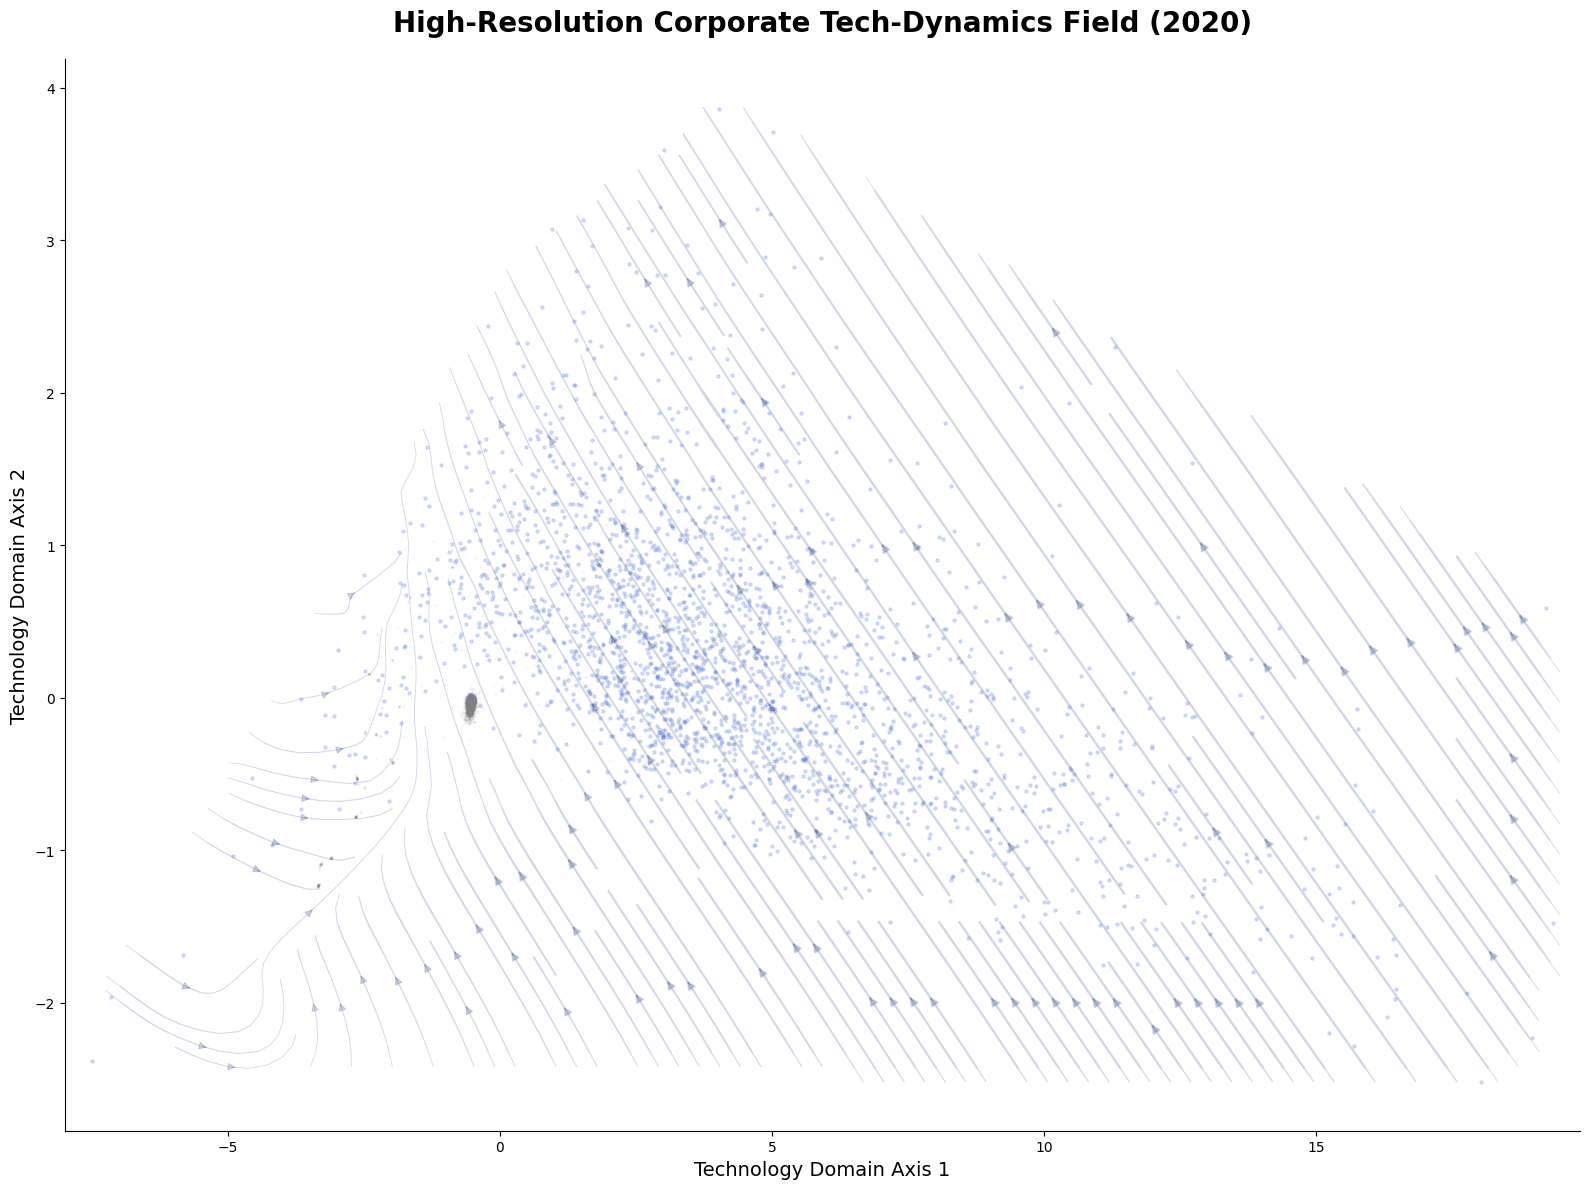

In [32]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
from scipy.interpolate import griddata

def visualize_global_vector_field_smooth(model, graph_dict, year, c_map):
    model.eval()
    data = graph_dict[year].to(device)
    num_corps = len(c_map)
    
    # 1. 潜在表現と速度ベクトルの抽出
    with torch.no_grad():
        node_indices = torch.arange(model.num_nodes, device=device)
        x = model.get_node_features(data.x, node_indices)
        mu, _ = model.encoder(x, data.edge_index)
        t = torch.tensor([0.0], device=device)
        velocity = model.temporal_predictor.ode_func(t, mu)
        
        z_np = mu.cpu().numpy()
        v_np = velocity.cpu().numpy()

    # 2. PCA投影と速度の計算
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    dt = 0.5
    v_2d = pca.transform(z_np + v_np * dt) - z_2d

    corp_z = z_2d[:num_corps]
    corp_v = v_2d[:num_corps]

    # 3. プロット設定
    fig, ax = plt.subplots(figsize=(16, 12), facecolor='white')
    
    # 背景の特許点 (極限まで薄く)
    ax.scatter(z_2d[num_corps:, 0], z_2d[num_corps:, 1], 
               c='gray', alpha=0.05, s=1)

    # 4. 高精細なグリッド構築 (60x60)
    # 空間の範囲を少し広めに設定して端まで描画
    x_min, x_max = corp_z[:,0].min() - 0.5, corp_z[:,0].max() + 0.5
    y_min, y_max = corp_z[:,1].min() - 0.5, corp_z[:,1].max() + 0.5
    grid_x, grid_y = np.mgrid[x_min:x_max:80j, y_min:y_max:80j]
    
    # 5. 滑らかな補間 (method='cubic')
    # cubicは非常に滑らかですが、データのない端で不安定になるため fill_value=0
    grid_vx = griddata(corp_z, corp_v[:,0], (grid_x, grid_y), method='cubic', fill_value=0)
    grid_vy = griddata(corp_z, corp_v[:,1], (grid_x, grid_y), method='cubic', fill_value=0)
    
    # 速度の強さを計算（線の太さに反映させるため）
    speed = np.sqrt(grid_vx**2 + grid_vy**2)
    lw = 2 * speed / speed.max() + 0.5 # 最小 0.5, 最大 2.5 の太さ

    # 6. 流線プロット (より高密度に)
    strm = ax.streamplot(grid_x[:,0], grid_y[0,:], grid_vx.T, grid_vy.T, 
                         color=(0.1, 0.2, 0.5, 0.2), # 薄いネイビー
                         linewidth=lw.T, 
                         density=2.5, # 密度を高く
                         arrowsize=1.2)

    # 全企業の位置（小さなドット）
    ax.scatter(corp_z[:, 0], corp_z[:, 1], c='royalblue', alpha=0.2, s=5)

    # 7. デザイン調整
    ax.set_title(f"High-Resolution Corporate Tech-Dynamics Field ({year})", 
                 fontsize=20, fontweight='bold', pad=20)
    ax.set_xlabel("Technology Domain Axis 1", fontsize=14)
    ax.set_ylabel("Technology Domain Axis 2", fontsize=14)
    
    # 枠線を消してスッキリさせる
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# 実行
last_year = sorted(graphs.keys())[-1]
visualize_global_vector_field_smooth(trained_model_ode, graphs, last_year, c_map)

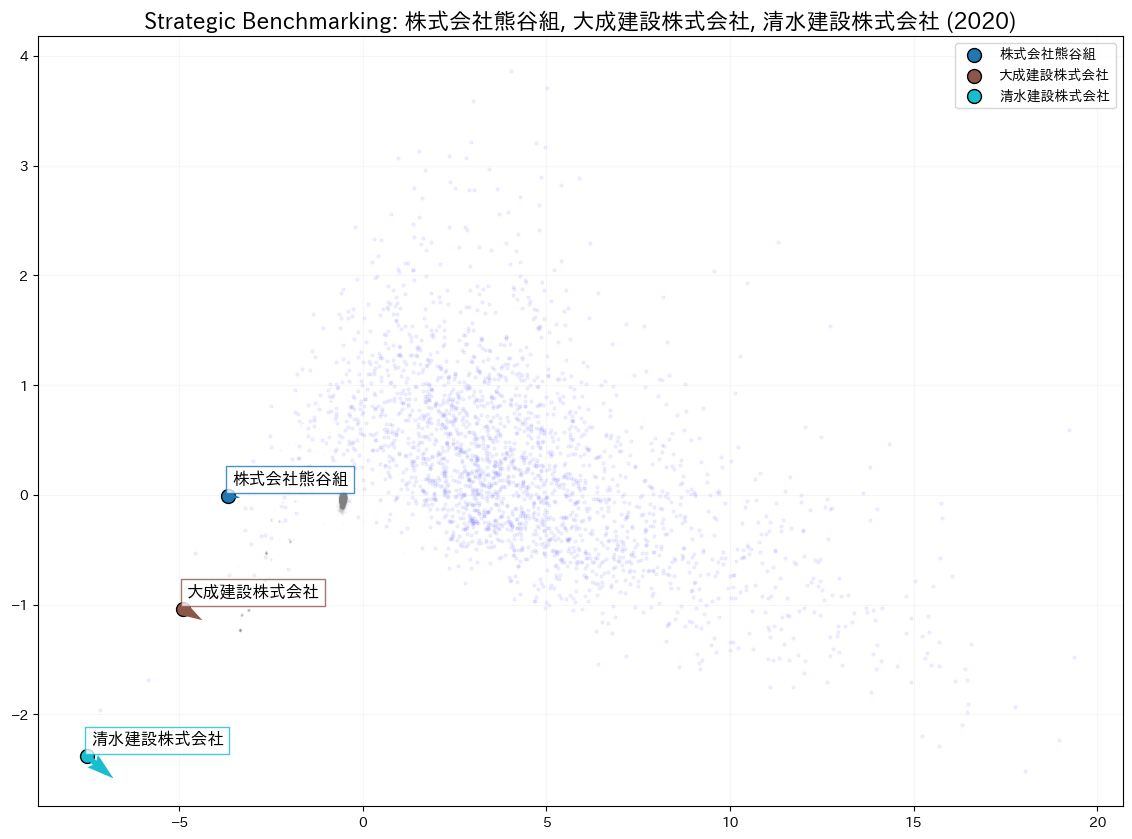

In [36]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
import japanize_matplotlib

def visualize_specific_companies(model, graph_dict, year, c_map, target_names):
    model.eval()
    data = graph_dict[year].to(device)
    num_corps = len(c_map)
    
    # 1. 潜在表現と速度ベクトルの抽出
    with torch.no_grad():
        node_indices = torch.arange(model.num_nodes, device=device)
        x = model.get_node_features(data.x, node_indices)
        mu, _ = model.encoder(x, data.edge_index)
        t = torch.tensor([0.0], device=device)
        velocity = model.temporal_predictor.ode_func(t, mu)
        
        z_np = mu.cpu().numpy()
        v_np = velocity.cpu().numpy()

    # 2. PCA投影（全体感は維持）
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    dt = 1.0 
    v_2d = pca.transform(z_np + v_np * dt) - z_2d

    # 3. ターゲット企業のインデックス取得
    target_indices = [c_map[name] for name in target_names if name in c_map]
    if not target_indices:
        print("指定された企業名がマップ内に見つかりませんでした。")
        return

    # 4. プロット
    plt.figure(figsize=(14, 10), facecolor='white')
    
    # 背景：全特許と全企業（極薄）
    plt.scatter(z_2d[num_corps:, 0], z_2d[num_corps:, 1], c='gray', alpha=0.02, s=1)
    plt.scatter(z_2d[:num_corps, 0], z_2d[:num_corps, 1], c='blue', alpha=0.05, s=5)

    # ターゲット企業の描画（色を変えて強調）
    colors = plt.cm.tab10(np.linspace(0, 1, len(target_indices)))
    
    for idx, color in zip(target_indices, colors):
        name = [k for k, v in c_map.items() if v == idx][0]
        cx, cy = z_2d[idx, 0], z_2d[idx, 1]
        cvx, cvy = v_2d[idx, 0], v_2d[idx, 1]
        
        # 現在地を大きく表示
        plt.scatter(cx, cy, color=color, s=100, edgecolors='black', zorder=10, label=name)
        
        # 進化ベクトル
        plt.quiver(cx, cy, cvx, cvy, color=color, alpha=1.0, 
                   scale=1, scale_units='xy', angles='xy', width=0.005, zorder=11)
        
        # 企業名の注釈
        plt.text(cx + 0.1, cy + 0.1, name, fontsize=12, fontweight='bold', 
                 color='black', bbox=dict(facecolor='white', alpha=0.8, edgecolor=color), zorder=12)

    plt.title(f"Strategic Benchmarking: {', '.join(target_names)} ({year})", fontsize=16)
    plt.grid(True, alpha=0.1)
    plt.legend(loc='upper right')
    
    plt.show()

# --- 実行例 ---
# 分析したい企業名をリストで指定（c_mapに含まれる正確な名前を入れてください）
my_targets = ["株式会社熊谷組", "大成建設株式会社", "清水建設株式会社"] 
last_year = sorted(graphs.keys())[-1]
visualize_specific_companies(trained_model_ode, graphs, last_year, c_map, my_targets)

In [38]:
df = preprocess_data('../dataset/topic_info3.csv')

1. データ読み込み開始...
2. 埋め込みベクトルを結合中...
  10000件処理済み...
  20000件処理済み...
  30000件処理済み...
  40000件処理済み...
  結合成功: 42789 件
3. 追加の前処理（企業名・日付）を実行中...
✓ 前処理完了: 19389 件（次元数: 1088）


In [39]:
df

,patent_number,patent_name,date,corporation,ipc,lead_ipc,fi,fterm,keyword,description,year,month,description_embedding,metadata_embedding,lead_inventor,inventors,year_month,topic_id,sim_score,combined_vector
23373,特開2011-147544,患者搬送装置,201001,[株式会社テクネット],[],A61G 5/00 (2006.01),[],[],"['簡単', '運搬']",場所を取らない簡単な構造により、感染患者等を隔離した状態で搬送することができる,2010,1,"[0.022907990962266922, 0.017237883061170578, -...",[ 0.34335172 -0.19837284 0.26558578 0.187770...,山口 一,"山口 一,伊澤 康一,梶間 智明,田中 勲,辻 裕次,三浦 靖弘,釜石 裕光",2010-01-01,1,0.898545,"[0.022907991, 0.017237883, -0.01705683, -0.029..."
23374,特開2011-147869,二酸化炭素の地中貯留施設およびその施工方法,201001,[清水建設株式会社],"['B01J 19/00 (2006.01)', 'E02D 29/045 (...",B01J 19/00 (2006.01),"['B01J 19/00 A', 'E02D 29/04 A', 'E0...","['2D047AB02', '4G075AA04', '2D147AB02']","['二酸化炭素', '貯留', '有効適切', '施工方法']",二酸化炭素の非構造型貯留層への貯留を可能とする有効適切な地中貯留施設とその施工方法を提供する,2010,1,"[0.030319971963763237, -0.015537390485405922, ...",[ 0.25184226 -0.23450097 0.24443543 0.197358...,米山 一幸,米山 一幸,2010-01-01,8,0.913877,"[0.030319972, -0.0155373905, -0.01071435, -0.0..."
23375,特開2011-149178,導枠及び海底探査方法,201001,"[株式会社熊谷組, 東光電気工事株式会社, 株式会社森長組]","['E02D 13/04 (2006.01)', 'E02D 27/52 (...",E02D 13/04 (2006.01),['E02D 13/04'],"['2D046DA62', '2D050AA06', '2D050CB14', '2D050...","['短期化', '施工コスト', '低減化']",工期の短縮化や施工コストの低減化を図る,2010,1,"[0.006442359182983637, 0.020957233384251595, -...",[ 3.8005432e-01 -2.2637601e-01 1.2717944e-01 ...,牛腸 明,"牛腸 明,矢嶋 英明,竹村 雅彦,岡野 雅史,島田 喜章,谷口 岩男",2010-01-01,5,0.926848,"[0.006442359, 0.020957233, -0.01782004, -0.052..."
23376,特開2011-149181,モノパイル式基礎施工方法,201001,"[株式会社熊谷組, 東光電気工事株式会社]","['E02D 7/00 (2006.01)', 'E02D 27/32 (...",E02D 7/00 (2006.01),"['E02D 7/00 A', 'E02D 27/32 A', 'E0...","['2D046CA08', '2D046DA05', '2D050AA01', '2D050...","['短期化', '施工コスト', '低減化']",工期の短縮化や施工コストの低減化を図る,2010,1,"[0.006442359182983637, 0.020957233384251595, -...",[ 0.37698632 -0.23764831 0.13028508 0.141271...,牛腸 明,"牛腸 明,矢嶋 英明,竹村 雅彦,岡野 雅史",2010-01-01,5,0.926848,"[0.006442359, 0.020957233, -0.01782004, -0.052..."
23377,特開2011-149182,杭基礎の施工方法,201001,[株式会社熊谷組],"['E02D 27/12 (2006.01)', 'E02D 27/16 (...",E02D 27/12 (2006.01),"['E02D 27/12 Z', 'E02D 27/16']","['2D046CA01', '2D046CA08']","['グラウト', '短期化', '施工コスト', '低減化']",グラウトの漏出を確実に防止すると共に、工期の短縮化や施工コストの低減化を図る,2010,1,"[-0.005412539932876825, 0.014347787015140057, ...",[ 0.3640074 -0.2338481 0.13964486 0.139466...,牛腸 明,"牛腸 明,矢嶋 英明",2010-01-01,3,0.933085,"[-0.00541254, 0.014347787, -0.023784904, -0.04..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42757,WO2021/140940,農産物栽培支援装置、農産物栽培システム、および農産物栽培支援方法,202012,"[株式会社大林組, 原嶋 寛, 住吉 栄作, 緒方 浩基]","['G06Q 50/02 (2012.01)', 'A01G 7/00 (...",G06Q 50/02 (2012.01),[],[],['測定値'],農産物栽培支援装置は、農業ハウスの栽培空間の複数の光合成要素について測定値を取得する,2020,12,"[0.0313706174492836, 0.01707536354660988, -0.0...",[ 0.19453254 -0.30019754 0.10449462 0.146774...,原嶋 寛,"原嶋 寛,住吉 栄作,緒方 浩基",2020-12-01,2,0.881575,"[0.031370617, 0.017075364, -0.03717448, -0.047..."
42758,WO2021/140941,収穫予測装置、収穫予測方法,202012,"[株式会社大林組, 中村 奈美]","['G06Q 50/02 (2012.01)', 'A01G 7/00 (...",G06Q 50/02 (2012.01),[],[],[],収穫予測装置は撮像部に接続された制御部を備える,2020,12,"[0.01752316951751709, 0.00962613895535469, -0....",[ 0.24668053 -0.2343066 0.18544462 0.098285...,中村 奈美,中村 奈美,2020-12-01,1,0.883478,"[0.01752317, 0.009626139, -0.019505411, -0.046..."
42759,特開2021-047923,情報処理システム及び情報処理システム用プログラム,202012,[高砂熱学工業株式会社],['G06Q 50/08 (2012.01)'],G06Q 50/08 (2012.01),['G06Q 50/08'],['5L049CC07'],"['建築現場', 'メンテナンス']",建築現場における管理を容易にする,2020,12,"[0.016471637412905693, 0.013141311705112457, -...",[ 0.27461112 -0.21962798 0.1781581 0.259755...,佐藤 彰洋,"佐藤 彰洋,鈴木 崇浩",2020-12-01,1,0.919058,"[0.016471637, 0.013141312, -0.039926685, -0.04..."
42760,特開2021-105333,天井点検口,202012,[前田建設工業株式会社],['E04F 19/08 (2006.01)'],E04F 19/08 (2006.01),[],[],"['軽微', '保守作業']",軽微な保守作業の実施時における操作性を向上させることができる天井点検口を提供する,2020,12,"[0.009724111296236515, 0.008886716328561306, -...",[ 0.26950538 -0.28889984 0.13830602 0.275950...,佐竹 晃,佐竹 晃,2020-12-01,5,0.920917,"[0.009724111, 0.008886716, -0

1. トピックごとの重心を計算中...


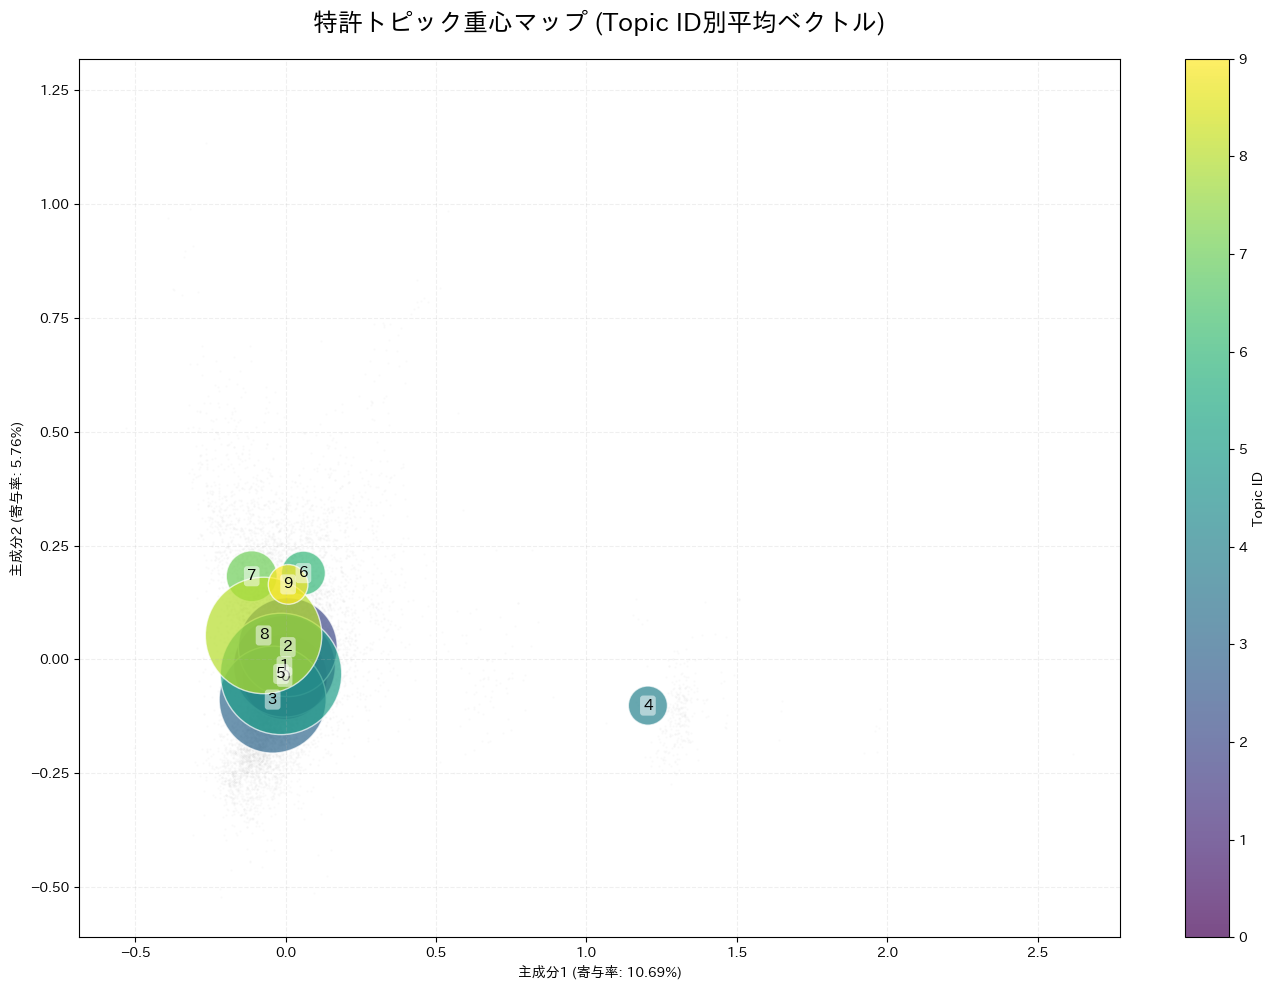

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import japanize_matplotlib

def plot_topic_id_centroids(df):
    """
    topic_idごとに特許ベクトルの平均（重心）を計算し、可視化する
    """
    print("1. トピックごとの重心を計算中...")
    
    # ベクトルのリストをnumpy配列に変換
    # combined_vectorが文字列の場合はパースが必要ですが、前処理済みの想定です
    all_vectors = np.stack(df['combined_vector'].values)
    
    # 2. 個別特許のPCA座標を計算（背景用）
    pca = PCA(n_components=2)
    coords_2d = pca.fit_transform(all_vectors)
    df['x'] = coords_2d[:, 0]
    df['y'] = coords_2d[:, 1]

    # 3. topic_id ごとに重心を計算
    # x, y の平均座標と、そのトピックに属する特許数を取得
    topic_centroids = df.groupby('topic_id').agg({
        'x': 'mean',
        'y': 'mean',
        'patent_number': 'count'
    }).reset_index()
    
    topic_centroids.columns = ['topic_id', 'center_x', 'center_y', 'patent_count']

    # 4. プロットの作成
    plt.figure(figsize=(14, 10), facecolor='white')
    
    # 背景：個別の全特許を非常に薄くプロット
    plt.scatter(df['x'], df['y'], c='lightgray', alpha=0.05, s=1, label='個別特許')

    # トピック重心のプロット
    # バブルサイズを特許数（ボリューム）に比例させる
    sizes = topic_centroids['patent_count'] * 2  # 見やすさのために倍率調整
    scatter = plt.scatter(topic_centroids['center_x'], topic_centroids['center_y'], 
                          s=sizes, c=topic_centroids['topic_id'], 
                          cmap='viridis', alpha=0.7, edgecolors='white', linewidth=1)

    # 5. 各トピックのIDをラベルとして表示
    for i, row in topic_centroids.iterrows():
        plt.text(row['center_x'], row['center_y'], str(int(row['topic_id'])), 
                 fontsize=11, fontweight='bold', ha='center', va='center',
                 bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2'))

    plt.title("特許トピック重心マップ (Topic ID別平均ベクトル)", fontsize=18, pad=20)
    plt.xlabel(f"主成分1 (寄与率: {pca.explained_variance_ratio_[0]:.2%})")
    plt.ylabel(f"主成分2 (寄与率: {pca.explained_variance_ratio_[1]:.2%})")
    
    # カラーバーでトピックIDのグラデーションを表示
    cbar = plt.colorbar(scatter)
    cbar.set_label('Topic ID')
    
    plt.grid(True, alpha=0.2, linestyle='--')
    plt.tight_layout()
    plt.show()

# 実行
plot_topic_id_centroids(df)

In [43]:
# 例：トピックID「5」の特許内容を確認する
target_id = 5
print(f"--- Topic ID: {target_id} の代表的な特許 ---")
print(df[df['topic_id'] == target_id]['patent_number'].head(5))
# もしタイトル等のテキストデータがあれば、それも表示
print(df[df['topic_id'] == target_id]['patent_name'].head(5))

--- Topic ID: 5 の代表的な特許 ---
23375    特開2011-149178
23376    特開2011-149181
23381    特開2011-149193
23383    特開2011-149215
23389    特開2011-144536
Name: patent_number, dtype: object
23375      導枠及び海底探査方法
23376    モノパイル式基礎施工方法
23381        免震装置設置方法
23383         ３次元免震装置
23389          吊り免震構造
Name: patent_name, dtype: object


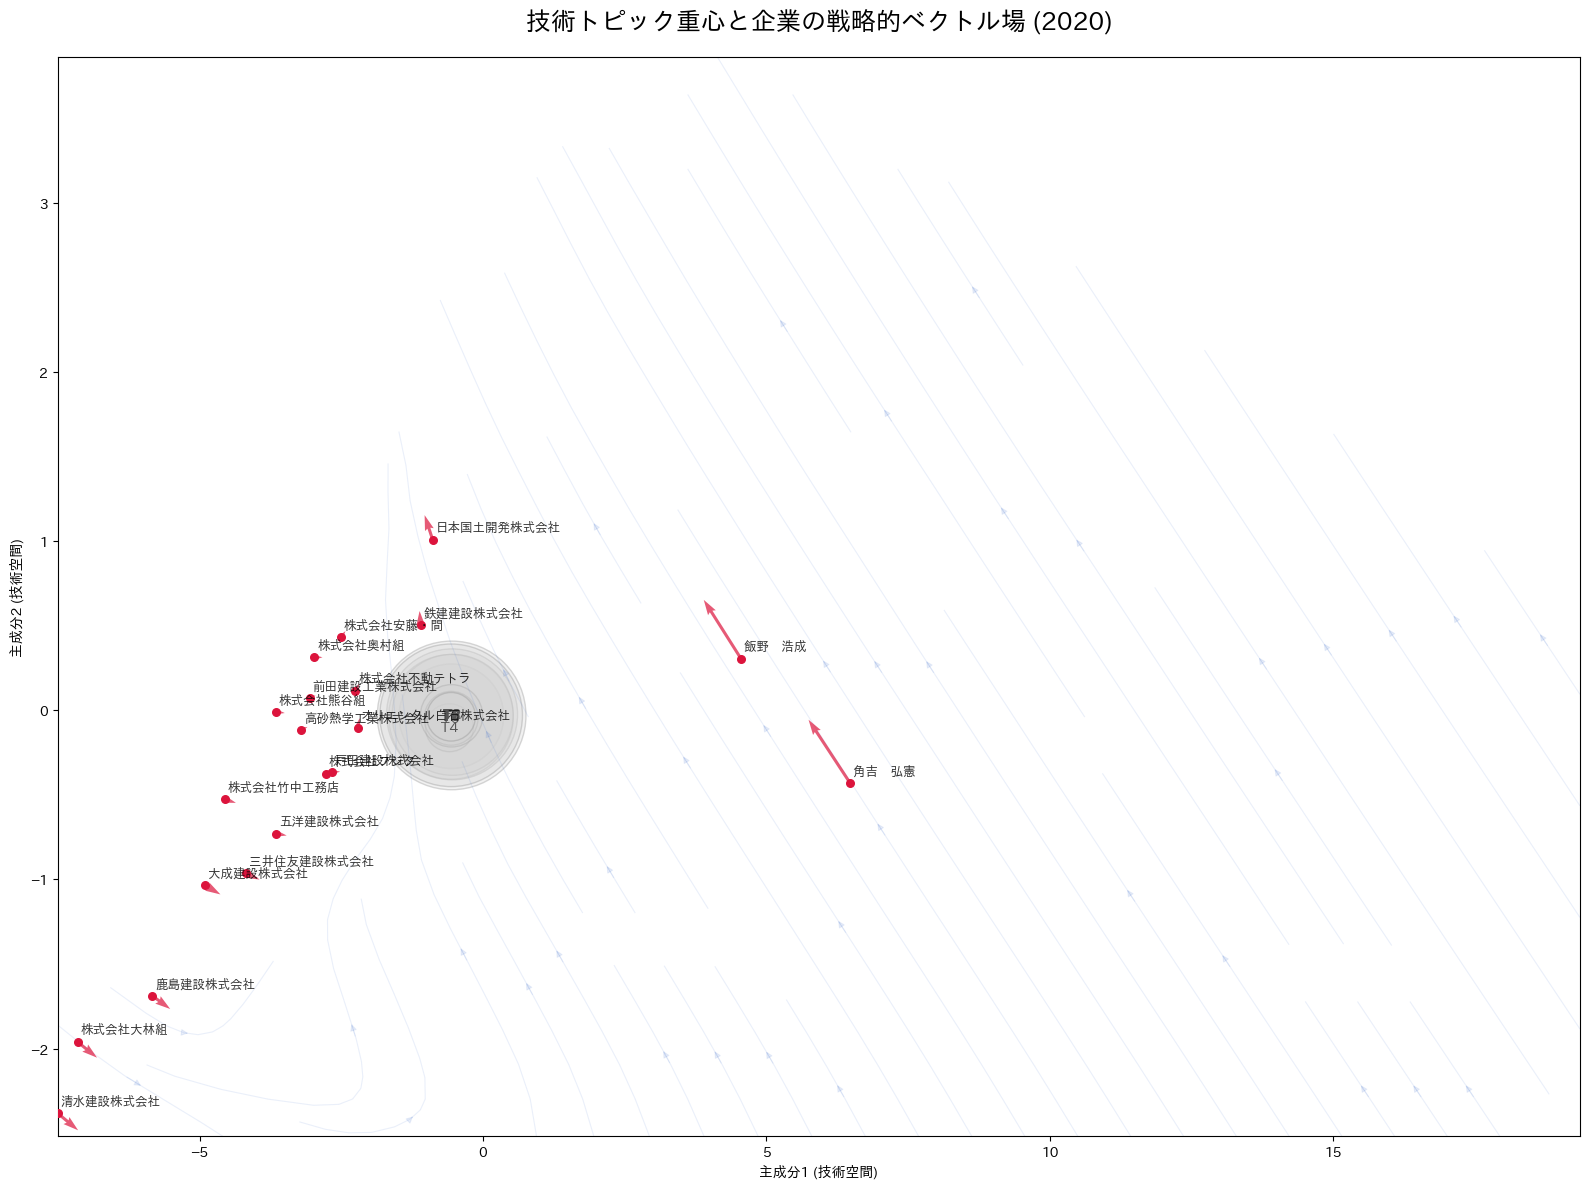

In [44]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
import japanize_matplotlib
from scipy.interpolate import griddata

def visualize_combined_topic_and_corp_field(model, graph_dict, year, df, c_map, p_map, n_top_corps=20):
    model.eval()
    data = graph_dict[year].to(device)
    num_corps = len(c_map)
    
    # 1. モデルの潜在空間 (mu) と速度 (velocity) の抽出
    with torch.no_grad():
        node_indices = torch.arange(model.num_nodes, device=device)
        x = model.get_node_features(data.x, node_indices)
        mu, _ = model.encoder(x, data.edge_index)
        t = torch.tensor([0.0], device=device)
        velocity = model.temporal_predictor.ode_func(t, mu)
        
        z_np = mu.cpu().numpy()
        v_np = velocity.cpu().numpy()

    # 2. PCA投影（モデルの潜在空間を2次元へ）
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    dt = 0.5
    v_2d = pca.transform(z_np + v_np * dt) - z_2d

    # 3. 特許ノードにtopic_idを紐付けて重心を計算
    # p_map を使ってモデル内のインデックスと特許番号を一致させる
    idx_to_patent = {v: k for k, v in p_map.items()}
    patent_indices = np.arange(num_corps, model.num_nodes)
    
    patent_data_list = []
    for idx in patent_indices:
        p_num = idx_to_patent[idx]
        # dfから該当特許のtopic_idを取得
        tid = df[df['patent_number'] == p_num]['topic_id'].values
        if len(tid) > 0:
            patent_data_list.append({
                'idx': idx,
                'topic_id': tid[0],
                'x': z_2d[idx, 0],
                'y': z_2d[idx, 1]
            })
    
    patent_df = pd.DataFrame(patent_data_list)
    topic_centroids = patent_df.groupby('topic_id').agg({'x': 'mean', 'y': 'mean', 'idx': 'count'}).reset_index()

    # 4. プロットの作成
    fig, ax = plt.subplots(figsize=(16, 12), facecolor='white')
    
    # --- 背景: トピック重心 (バブル) ---
    sizes = topic_centroids['idx'] * 3  # 特許数に応じてサイズ調整
    ax.scatter(topic_centroids['x'], topic_centroids['y'], s=sizes, c='lightgray', 
               alpha=0.3, edgecolors='gray', label='技術トピック重心')
    
    for i, row in topic_centroids.iterrows():
        ax.text(row['x'], row['y'], f"T{int(row['topic_id'])}", fontsize=10, 
                ha='center', va='center', fontweight='bold', color='#555555')

    # --- 中景: 全企業の流線 (Streamplot) ---
    corp_z = z_2d[:num_corps]
    corp_v = v_2d[:num_corps]
    x_range = np.linspace(z_2d[:,0].min(), z_2d[:,0].max(), 50)
    y_range = np.linspace(z_2d[:,1].min(), z_2d[:,1].max(), 50)
    grid_x, grid_y = np.meshgrid(x_range, y_range)
    grid_vx = griddata(corp_z, corp_v[:,0], (grid_x, grid_y), method='linear', fill_value=0)
    grid_vy = griddata(corp_z, corp_v[:,1], (grid_x, grid_y), method='linear', fill_value=0)
    
    ax.streamplot(x_range, y_range, grid_vx, grid_vy, color=(0.2, 0.4, 0.8, 0.1), linewidth=0.8)

    # --- 前景: 主要企業のベクトル ---
    edge_index = data.edge_index.cpu().numpy()
    counts = np.bincount(edge_index[0], minlength=model.num_nodes)[:num_corps]
    top_indices = np.argsort(counts)[-n_top_corps:][::-1]
    idx_to_corp = {v: k for k, v in c_map.items()}

    for idx in top_indices:
        name = idx_to_corp[idx]
        cx, cy = z_2d[idx, 0], z_2d[idx, 1]
        cvx, cvy = v_2d[idx, 0], v_2d[idx, 1]
        
        ax.scatter(cx, cy, c='crimson', s=30, zorder=5)
        ax.quiver(cx, cy, cvx, cvy, color='crimson', alpha=0.7, scale=1, 
                  scale_units='xy', angles='xy', width=0.002, zorder=6)
        ax.text(cx + 0.05, cy + 0.05, name, fontsize=9, alpha=0.8, zorder=7)

    ax.set_title(f"技術トピック重心と企業の戦略的ベクトル場 ({year})", fontsize=18, pad=20)
    ax.set_xlabel("主成分1 (技術空間)")
    ax.set_ylabel("主成分2 (技術空間)")
    plt.tight_layout()
    plt.show()

# 実行
last_year = sorted(graphs.keys())[-1]
visualize_combined_topic_and_corp_field(trained_model_ode, graphs, last_year, df, c_map, p_map)

In [7]:
# ============================================================
# セルA: 比較手法（DySAT, EvolveGCN, ROLAND）の定義と学習
# ============================================================
import torch.nn as nn

# 1. DySAT風: Structural + Temporal Attention
class DySATPredictor(nn.Module):
    def __init__(self, latent_dim, num_heads=4):
        super().__init__()
        self.temporal_attention = nn.MultiheadAttention(
            embed_dim=latent_dim, num_heads=num_heads, batch_first=True
        )
    def forward(self, z_history_list):
        # [batch, seq_len, dim] に変換
        z_stack = torch.stack(z_history_list, dim=1)
        # 時間軸に対して自己アテンションを適用
        attn_out, _ = self.temporal_attention(z_stack, z_stack, z_stack)
        return attn_out[:, -1, :] # 最終時刻の表現を返す

# 2. EvolveGCN風: RNNによるノード表現の進化
class EvolveGCNPredictor(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.gru = nn.GRUCell(latent_dim, latent_dim)
    def forward(self, z_history_list):
        # 簡易版: 各ステップの潜在表現を順次GRUで処理
        h = z_history_list[0]
        for i in range(1, len(z_history_list)):
            h = self.gru(z_history_list[i], h)
        return h

# 3. ROLAND風: Recurrent GNN State Update
class RolandPredictor(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.gru = nn.GRUCell(latent_dim, latent_dim)
    def forward(self, z_history_list):
        # 最新の入力を受け取り、過去の隠れ状態（履歴の平均など）を更新
        # 本来は学習中ずっと隠れ状態を保持するが、ここでは簡易的にシーケンス処理
        h = z_history_list[0]
        for i in range(1, len(z_history_list)):
            h = self.gru(z_history_list[i], h)
        return h

# --- モデル学習の実行 ---
# 追加したいモデルのリスト
predictor_configs = [
    ('dysat', DySATPredictor(16)),
    ('evolvegcn', EvolveGCNPredictor(16)),
    ('roland', RolandPredictor(16))
]

results_extended = []

for name, predictor in predictor_configs:
    print(f"\n>>> 比較手法: {name.upper()} の学習開始")
    # UnifiedVGAEをカスタマイズして実行
    model_custom = UnifiedVGAE(
        num_nodes=total_n, num_corps=num_corps, input_dim=input_dim,
        hidden_dim=64, latent_dim=16, predictor_type='rnn', # ベースはRNN枠を使用
        sequence_length=sequence_length_k
    )
    # 予測器を差し替え
    model_custom.temporal_predictor = predictor.to(device)
    
    trained_m, best_mrr, hist, duration = train_model_improved(
        model_custom, graphs, num_corps, f"VGAE+{name}", 
        historical_edges, num_epochs=20
    )
    results_extended.append((name, best_mrr, duration))

# 結果のサマリー表示
print("\n" + "="*50)
print(f"{'Method':<15} | {'MRR':<10} | {'Time(s)':<10}")
print("-" * 50)
for n, m, d in results_extended:
    print(f"{n:<15} | {m:<10.4f} | {d:<10.2f}")


>>> 比較手法: DYSAT の学習開始

=== VGAE+dysat (k=3) 学習開始 ===
学習年: [2013, 2014, 2015, 2016, 2017, 2018, 2019], 検証: 2017..2019 -> 2020
Epoch  0: Loss=12.5903, FutureLoss=4.1787, Val MRR=0.0493, Hits@10=0.091
✓ Best model! MRR: 0.0493
Epoch  5: Loss=8.1831, FutureLoss=2.6937, Val MRR=0.0476, Hits@10=0.091
Epoch 10: Loss=7.0770, FutureLoss=2.3392, Val MRR=0.0571, Hits@10=0.124
✓ Best model! MRR: 0.0571
Epoch 15: Loss=6.8135, FutureLoss=2.3787, Val MRR=0.0507, Hits@10=0.091
✓ VGAE+dysat 学習完了 (所要時間: 340.29秒)

>>> 比較手法: EVOLVEGCN の学習開始

=== VGAE+evolvegcn (k=3) 学習開始 ===
学習年: [2013, 2014, 2015, 2016, 2017, 2018, 2019], 検証: 2017..2019 -> 2020
Epoch  0: Loss=12.2778, FutureLoss=4.0491, Val MRR=0.0478, Hits@10=0.101
✓ Best model! MRR: 0.0478
Epoch  5: Loss=8.4032, FutureLoss=2.7478, Val MRR=0.0504, Hits@10=0.106
✓ Best model! MRR: 0.0504
Epoch 10: Loss=7.7145, FutureLoss=2.5185, Val MRR=0.0554, Hits@10=0.119
✓ Best model! MRR: 0.0554
Epoch 15: Loss=6.9893, FutureLoss=2.2498, Val MRR=0.0656, Hits@10=0.11

In [ ]:
# ============================================================
# セル1: ライブラリのインポートと初期設定
# ============================================================
import pandas as pd
import numpy as np
import ast
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint
from sklearn.metrics import roc_auc_score, average_precision_score
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time
import os
import warnings
import pickle
import json
from datetime import datetime
from collections import defaultdict
import time

warnings.filterwarnings('ignore')

# 再現性のためのシード設定
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ============================================================
# セル2: データ前処理関数の定義
# ============================================================
def safe_parse_embedding(x):
    """埋め込みベクトルを柔軟にパースする"""
    if pd.isna(x) or x == "":
        return None
    
    if isinstance(x, (list, np.ndarray)):
        return np.array(x, dtype=np.float32)
    
    if isinstance(x, str):
        try:
            s = re.sub(r'[\[\]\n]', '', x)
            s = s.replace(',', ' ')
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except Exception:
            return None
    return None

def preprocess_data(file_path):
    """データ前処理のメイン関数"""
    print("1. データ読み込み開始...")
    df = pd.read_csv(file_path)
    
    print("2. 埋め込みベクトルを結合中...")
    combined_vectors = []
    valid_indices = []
    
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row['description_embedding'])
        meta = safe_parse_embedding(row['metadata_embedding'])
        
        if desc is not None and meta is not None:
            combined_vectors.append(np.concatenate([desc, meta]))
            valid_indices.append(i)
        
        if i % 10000 == 0 and i > 0:
            print(f"  {i}件処理済み...")

    if not combined_vectors:
        print("⚠️ ベクトルが生成されません。データの中身を確認してください。")
        return pd.DataFrame()

    df = df.iloc[valid_indices].copy()
    df['combined_vector'] = combined_vectors
    print(f"  結合成功: {len(df)} 件")

    print("3. 追加の前処理（企業名・日付）を実行中...")
    def parse_corp(x):
        try:
            return ast.literal_eval(x) if isinstance(x, str) else x
        except:
            return x
    
    df["corporation"] = df["corporation"].apply(parse_corp)
    df['year_month'] = pd.to_datetime(df['year_month'])
    df = df[(df['year_month'] >= '2010-01-01') & (df['year_month'] <= '2020-12-31')]
    
    if len(df) > 0:
        v_dim = len(df.iloc[0]['combined_vector'])
        print(f"✓ 前処理完了: {len(df)} 件（次元数: {v_dim}）")
    else:
        print("⚠️ 日付フィルタリング後にデータが0件になりました。")
        
    return df


# ============================================================
# セル3: データ前処理の実行
# ============================================================
df = preprocess_data('../dataset/topic_info3.csv')
print(f"\n処理済みデータ形状: {df.shape}")
if len(df) > 0:
    print(f"ベクトル次元数: {len(df.iloc[0]['combined_vector'])}")


# ============================================================
# セル4: 動的グラフ構築関数の定義
# ============================================================
def build_global_graphs(df):
    """動的グラフの構築"""
    all_corporations = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    
    corp_to_idx = {corp: i for i, corp in enumerate(all_corporations)}
    patent_to_idx = {patent: i + len(all_corporations) for i, patent in enumerate(all_patents)}
    total_nodes = len(all_corporations) + len(all_patents)
    
    print(f"企業数: {len(all_corporations)}, 特許数: {len(all_patents)}")
    
    # 特許特徴量の準備
    patent_features = {}
    for _, row in df.iterrows():
        patent_features[row['patent_number']] = row['combined_vector']

    global_graph_dict = {}
    year_groups = df.groupby(df['year_month'].dt.year)
    
    # 各年のリンク履歴を保存（Historical Negatives用）
    all_historical_edges = set()
    
    for year, group in year_groups:
        edges = []
        active_nodes = set()
        
        for _, row in group.iterrows():
            p_idx = patent_to_idx[row['patent_number']]
            active_nodes.add(p_idx)
            for corp in row['corporation']:
                c_idx = corp_to_idx[corp]
                edges.append([c_idx, p_idx])
                active_nodes.add(c_idx)
                all_historical_edges.add((c_idx, p_idx))
        
        if not edges:
            continue
        
        # 特徴行列の初期化
        input_dim = len(next(iter(patent_features.values())))
        x = torch.zeros(total_nodes, input_dim)
        for p_num, p_idx in patent_to_idx.items():
            if p_num in patent_features:
                x[p_idx] = torch.tensor(patent_features[p_num])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[list(active_nodes)] = True
        
        global_graph_dict[year] = Data(
            x=x, 
            edge_index=edge_index, 
            active_mask=active_mask, 
            year=year,
            num_nodes=total_nodes
        )
        
    return global_graph_dict, all_corporations, all_patents, patent_to_idx, total_nodes, corp_to_idx, all_historical_edges


# ============================================================
# セル5: 動的グラフの構築実行
# ============================================================
graphs, corps, patents, p_map, total_n, c_map, historical_edges = build_global_graphs(df)
num_corps = len(corps)

print(f"\n構築完了:")
print(f"  総ノード数: {total_n}")
print(f"  企業数: {num_corps}")
print(f"  特許数: {len(patents)}")
print(f"  年数: {len(graphs)}")
print(f"  年度: {sorted(graphs.keys())}")
print(f"  履歴エッジ数: {len(historical_edges)}")


# ============================================================
# セル6: 新しい評価指標の実装（MRR, Hits@K）
# ============================================================
def compute_ranking_metrics(model, z_pred, pos_edges, num_corps, all_true_edges, k_values=[1, 3, 10, 50]):
    """
    Filtered MRRとHits@Kを計算する関数
    all_true_edges: 学習・検証・テストに含まれる全正解エッジの (src, dst) セット
    """
    model.eval()
    if pos_edges.size(1) == 0:
        return None
    
    # アクティブな企業と特許を取得
    active_corps = torch.unique(pos_edges[0][pos_edges[0] < num_corps])
    active_patents = torch.unique(pos_edges[1][pos_edges[1] >= num_corps])
    
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    reciprocal_ranks = []
    hits_at_k = {k: [] for k in k_values}
    
    # 計算効率のため最大1000個
    num_eval = min(pos_edges.size(1), 1000)

    # 各正例エッジについてランキングを計算
    for i in range(min(pos_edges.size(1), 1000)):  # 計算効率のため最大1000個
        src, dst = pos_edges[0, i].item(), pos_edges[1, i].item()
        filtered_negs = []
        attempts = 0
        #99個の「真のふれい（どのデータセットにも存在しないエッジ）」を探す

        # 負例候補を生成（同じ企業から他の特許へのリンク）
        neg_candidates = active_patents[active_patents != dst]
        if len(neg_candidates) < 99:
            continue
        
        # ランダムに99個サンプリング
        while len(filtered_negs) < 99 and attempts < 1000:
            neg_dst = active_patents[torch.randint(len(active_patents), (1,))].item()
            # ターゲット(src, dst)そのものではなく、かつ全正解データに含まれていない場合のみ採用
            if neg_dst != dst and (src, neg_dst) not in all_true_edges:
                filtered_negs.append(neg_dst)
            attempts += 1
        
        if len(filtered_negs) < 99:
            continue # 負例が十分に確保できない場合はスキップ
            
        # 正例1個 + 負例99個
        all_dsts = torch.tensor([dst] + filtered_negs, device=device)
        src_repeated = torch.tensor([src] * len(all_dsts), device=device)
        candidate_edges = torch.stack([src_repeated, all_dsts])
        
        with torch.no_grad():
            scores = model.decode(z_pred, candidate_edges).cpu().numpy()
        
        # 順位計算（高いスコアほど上位）
        rank = (scores > scores[0]).sum() + 1
        reciprocal_ranks.append(1.0 / rank)
        
        for k in k_values:
            hits_at_k[k].append(1.0 if rank <= k else 0.0)
    
    if not reciprocal_ranks:
        return None
    
    metrics = {'mrr': np.mean(reciprocal_ranks), 'num_samples': len(reciprocal_ranks)}
    for k in k_values:
        metrics[f'hits@{k}'] = np.mean(hits_at_k[k])
    
    return metrics


# ============================================================
# セル7: ベースラインモデル - EdgeBank
# ============================================================
class EdgeBank:
    """
    記憶ベースのベースラインモデル
    過去に観測されたエッジを記憶し、それに基づいて予測を行う
    """
    def __init__(self, mode='time_window', window_size=2):
        """
        Args:
            mode: 'time_window' (直近のウィンドウのみ) or 'unlimited' (全履歴)
            window_size: time_windowモードの場合のウィンドウサイズ（年数）
        """
        self.mode = mode
        self.window_size = window_size
        self.edge_memory = set()
        
    def update(self, graph_dict, current_year):
        """指定された年までのエッジを記憶"""
        self.edge_memory.clear()
        years = sorted(graph_dict.keys())
        
        if self.mode == 'time_window':
            start_year = max(years[0], current_year - self.window_size + 1)
            relevant_years = [y for y in years if start_year <= y <= current_year]
        else:  # unlimited
            relevant_years = [y for y in years if y <= current_year]
        
        for year in relevant_years:
            edges = graph_dict[year].edge_index.t().tolist()
            self.edge_memory.update([tuple(e) for e in edges])
    
    def predict(self, candidate_edges):
        """候補エッジのスコアを計算（記憶にあれば1.0、なければ0.0）"""
        scores = []
        for i in range(candidate_edges.size(1)):
            edge = (candidate_edges[0, i].item(), candidate_edges[1, i].item())
            scores.append(1.0 if edge in self.edge_memory else 0.0)
        return np.array(scores)
    
    def evaluate_ranking(self, test_edges, num_corps, active_patents):
        """ランキング評価"""
        reciprocal_ranks = []
        
        for i in range(min(test_edges.size(1), 1000)):
            src, dst = test_edges[0, i].item(), test_edges[1, i].item()
            
            neg_candidates = active_patents[active_patents != dst]
            if len(neg_candidates) < 99:
                continue
            
            sampled_negs = neg_candidates[torch.randperm(len(neg_candidates))[:99]]
            all_dsts = torch.cat([torch.tensor([dst]), sampled_negs])
            
            scores = []
            for d in all_dsts:
                edge = (src, d.item())
                scores.append(1.0 if edge in self.edge_memory else 0.0)
            
            scores = np.array(scores)
            # 正解(index 0)以上のスコアを持つエッジをカウント
            # 全員0点なら count は 100 (正解1 + 負例99) になります
            num_better_or_equal = (scores >= scores[0]).sum()
            
            # 正解(index 0)より高いスコアを持つエッジをカウント
            num_better = (scores > scores[0]).sum()
            
            # 同点(タイ)がある場合の平均順位を計算（これが最も公平な手法です）
            # 全員0点なら、(0 + 100 + 1) / 2 = 50.5位 となります
            rank = (num_better + num_better_or_equal + 1) / 2.0
            reciprocal_ranks.append(1.0 / rank)
        
        return {'mrr': np.mean(reciprocal_ranks)} if reciprocal_ranks else None


# ============================================================
# セル8: ベースラインモデル - GraphMixer
# ============================================================
class GraphMixer(nn.Module):
    """
    シンプルなMLPベースのベースラインモデル
    時間エンコーディングとMean Poolingのみを使用
    """
    def __init__(self, input_dim, hidden_dim=64, latent_dim=16):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        # ノード特徴エンコーダ
        self.node_encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        
        # 時間エンコーディング
        self.time_encoder = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        
        # リンク予測器
        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )
    
    def encode(self, x, time_delta=0.0):
        """ノード特徴と時間情報をエンコード"""
        node_emb = self.node_encoder(x)
        time_emb = self.time_encoder(torch.tensor([[time_delta]], device=x.device))
        return node_emb + time_emb.expand(node_emb.size(0), -1)
    
    def decode(self, z, edge_index):
        """リンク予測"""
        z_i = z[edge_index[0]]
        z_j = z[edge_index[1]]
        combined = torch.cat([z_i, z_j], dim=-1)
        return torch.sigmoid(self.link_predictor(combined)).squeeze()


# ============================================================
# セル9: モデルクラスの定義（エンコーダ）
# ============================================================
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels * 2, hidden_channels, heads=2, concat=False)
        self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1, concat=False)
        self.conv_mu = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.dropout = nn.Dropout(0.2)
        self.batch_norm1 = nn.BatchNorm1d(hidden_channels * 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.batch_norm1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)


# ============================================================
# セル10: 時系列予測器の定義（ODE, MLP, RNN, LSTM）
# ============================================================
class ODEFunc(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim + 1, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, latent_dim)
        )
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        t_vec = t.expand(z.size(0), 1)
        z_t = torch.cat([z, t_vec], dim=1)
        dz = self.net(z_t)
        return torch.tanh(self.scale) * dz

class NeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.ode_func = ODEFunc(latent_dim, hidden_dim)

    def forward(self, z_current, delta_t=0.5):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        try:
            z_future = odeint(
                self.ode_func, z_current, t_span,
                method='dopri5', rtol=1e-4, atol=1e-4,
                options={'max_num_steps': 1000}
            )[-1]
            
            if torch.isnan(z_future).any() or torch.isinf(z_future).any():
                print("Warning: ODE solution contains NaN/Inf")
                return z_current
            return z_future
        except Exception as e:
            print(f"ODE予測エラー: {e}")
            return z_current

# ============================================================
# セル10 (修正): ポテンシャル関数と勾配ODEFuncの定義
# ============================================================

class PotentialNet(nn.Module):
    """座標zにおける「注目度（企業の集積度）」を計算するネットワーク"""
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Softplus(),  # 勾配を滑らかにするためにReLUではなくSoftplus
            nn.Linear(hidden_dim, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, 1) # 出力はスカラー1次元
        )

    def forward(self, z):
        return self.net(z)

class GradientODEFunc(nn.Module):
    """ポテンシャルの勾配を速度ベクトルとして返すODE関数"""
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        # 勾配（微分）を計算するために計算グラフを保持
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            # Phiをzで微分:これが「注目度が上がる方向」
            # phi.sum()としているのは、バッチ全体の勾配を一括計算するため
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        
        # 学習可能なスケールを適用して速度を調整
        return torch.tanh(self.scale) * grad_z

class GradientNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func = GradientODEFunc(self.potential_net)

    def forward(self, z_current, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        z_future = odeint(
            self.ode_func, z_current, t_span,
            method='dopri5', rtol=1e-3, atol=1e-3
        )[-1]
        return z_future

class AugmentedODEFunc(nn.Module):
    def __init__(self, latent_dim, augment_dim, hidden_dim):
        super().__init__()
        # 入力次元 = 潜在次元 + 拡張次元
        self.total_dim = latent_dim + augment_dim
        self.net = nn.Sequential(
            nn.Linear(self.total_dim + 1, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.Softplus(), # ODEの滑らかさを保つためにSoftplusが推奨されます
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, self.total_dim)
        )
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, x):
        t_vec = t.expand(x.size(0), 1)
        x_t = torch.cat([x, t_vec], dim=1)
        dx = self.net(x_t)
        return torch.tanh(self.scale) * dx

class AugmentedNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, augment_dim, hidden_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.augment_dim = augment_dim
        self.ode_func = AugmentedODEFunc(latent_dim, augment_dim, hidden_dim)

    def forward(self, z_current, delta_t=0.5):
        # 1. 拡張次元を0で埋めて結合する [batch, latent + augment]
        batch_size = z_current.size(0)
        aug = torch.zeros(batch_size, self.augment_dim).to(z_current.device)
        x_augmented = torch.cat([z_current, aug], dim=1)
        
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        try:
            # 2. 拡張された空間でODEを解く
            x_final = odeint(
                self.ode_func, x_augmented, t_span,
                method='dopri5', rtol=1e-4, atol=1e-4
            )[-1]
            
            # 3. 元の潜在次元部分だけを抽出して返す
            z_future = x_final[:, :self.latent_dim]
            return z_future
        except Exception as e:
            print(f"ANODE予測エラー: {e}")
            return z_current

class MLPPredictor(nn.Module):
    def __init__(self, sequence_length, latent_dim, hidden_dim):
        super().__init__()
        self.sequence_length = sequence_length
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            nn.Linear(sequence_length * latent_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, latent_dim)
        )

    def forward(self, z_history_list):
        try:
            z_concat = torch.cat(z_history_list, dim=-1)
            return self.net(z_concat)
        except Exception as e:
            print(f"MLP Predictor エラー: {e}")
            return z_history_list[-1]

class RNNPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim, num_layers=2):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=latent_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True,
            dropout=0.2 if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim, latent_dim)

    def forward(self, z_history_list):
        try:
            z_stack = torch.stack(z_history_list, dim=1)
            _, h_n = self.rnn(z_stack)
            z_pred = self.fc(h_n[-1])
            return z_pred
        except Exception as e:
            print(f"RNN Predictor エラー: {e}")
            return z_history_list[-1]

class LSTMPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=latent_dim, 
            hidden_size=hidden_dim,
            num_layers=num_layers, 
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim, latent_dim)

    def forward(self, z_history_list):
        try:
            # z_history_list: [batch_size, seq_len, latent_dim] に変換
            z_stack = torch.stack(z_history_list, dim=1)
            # LSTMの出力: (output, (h_n, c_n))
            _, (h_n, _) = self.lstm(z_stack)
            # 最終層の隠れ状態を使用して予測
            z_pred = self.fc(h_n[-1])
            return z_pred
        except Exception as e:
            print(f"LSTM Predictor エラー: {e}")
            return z_history_list[-1]

# ============================================================
# セル14.5: 長期予測（再帰的マルチステップ）評価関数の定義
# ============================================================
def evaluate_long_term(model, initial_history, global_graph_dict, num_corps, max_steps=5):
    """
    1年先から最大5年先までのMRRを計算する
    """
    model.eval()
    results = {}
    years = sorted(global_graph_dict.keys())
    
    # 履歴の最終年から数えて、テストデータの開始位置を特定
    last_hist_year = initial_history[-1].year
    test_start_idx = years.index(last_hist_year) + 1
    
    # フィルタ評価用の全正解エッジ
    all_true_edges = set()
    for y in years:
        all_true_edges.update([tuple(map(int, e)) for e in global_graph_dict[y].edge_index.t().tolist()])

    with torch.no_grad():
        node_indices = torch.arange(model.num_nodes, device=device)
        # 初期状態の潜在表現リストを作成
        z_history = []
        for data in initial_history:
            x_f = model.get_node_features(data.x, node_indices)
            # UnifiedVGAEならエンコーダのmuを取得、Staticならそのまま
            if hasattr(model, 'encoder'):
                mu, _ = model.encoder(x_f, data.edge_index)
            else:
                mu = model.encode(data.x, data.edge_index)
            z_history.append(mu)

        # 1年〜max_steps年先まで予測を繰り返す
        for s in range(1, max_steps + 1):
            target_idx = test_start_idx + s - 1
            if target_idx >= len(years):
                break # データが存在しない場合は終了
            
            target_year = years[target_idx]
            data_target = global_graph_dict[target_year].to(device)
            
            # 未来の潜在表現を予測
            z_pred = model.predict_future(z_history)
            
            # MRRを計算
            metrics = compute_ranking_metrics(model, z_pred, data_target.edge_index, num_corps, all_true_edges)
            results[f'{s}年先 ({target_year})'] = metrics['mrr'] if metrics else 0.0
            
            # 重要：予測された潜在表現を次の履歴に加えて再帰的に予測
            z_history.pop(0)
            z_history.append(z_pred)
            
    return results

# ============================================================
# セル11: 統合VGAEモデルの定義
# ============================================================
class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=256,
                 latent_dim=64, predictor_type='ode', sequence_length=3, augment_dim=4):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.predictor_type = predictor_type
        self.latent_dim = latent_dim
        self.input_dim = input_dim
        self.sequence_length = sequence_length

        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)

        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)

        if predictor_type == 'ode':
            self.temporal_predictor = NeuralODEPredictor(latent_dim, hidden_dim)
        elif predictor_type == 'gradient_ode': 
            self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)
        elif predictor_type == 'anode':
            self.temporal_predictor = AugmentedNeuralODEPredictor(latent_dim, augment_dim, hidden_dim=hidden_dim)
        elif predictor_type == 'mlp':
            self.temporal_predictor = MLPPredictor(sequence_length, latent_dim, hidden_dim)
        elif predictor_type == 'rnn':
            self.temporal_predictor = RNNPredictor(latent_dim, hidden_dim)
        elif predictor_type == 'lstm':
            self.temporal_predictor = LSTMPredictor(latent_dim, hidden_dim)
        else:
            raise ValueError(f"サポートされていない predictor_type: {predictor_type}")

        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )
        
        self.generative_decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, input_dim)
        )

    def get_node_features(self, x, node_indices=None):
        if node_indices is not None:
            features = x.clone()
            corp_mask = node_indices < self.num_corps
            if corp_mask.any():
                corp_indices = node_indices[corp_mask]
                features[corp_mask] = self.corp_embeddings(corp_indices)
            return features
        return x

    def encode(self, x, edge_index, node_indices=None):
        edge_index = edge_index.long()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        x_features = self.get_node_features(x, node_indices)
        mu, logvar = self.encoder(x_features, edge_index)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu

    def decode(self, z, edge_index):
        edge_index = edge_index.long()
        z_i = z[edge_index[0]]
        z_j = z[edge_index[1]]
        combined = torch.cat([z_i, z_j], dim=-1)
        return torch.sigmoid(self.link_predictor(combined)).squeeze()

    def predict_future(self, z_history_list):
        try:
            if self.predictor_type in ['ode', 'anode']:
                z_current = z_history_list[-1]
                return self.temporal_predictor(z_current)
            elif self.predictor_type in ['mlp', 'rnn', 'lstm']:
                return self.temporal_predictor(z_history_list)
            else:
                raise ValueError(f"予期しない predictor_type: {self.predictor_type}")
        except Exception as e:
            print(f"時系列予測エラー ({self.predictor_type}): {e}")
            return z_history_list[-1]

# ============================================================
# セル11.5: StaticVGAE（静的ベースライン）の定義
# ============================================================
class StaticVGAE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=16):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        # 学習ループで参照されるため
        self.sequence_length = 1
        
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def get_node_features(self, x, node_indices):
        features = x.clone()
        corp_mask = node_indices < self.num_corps
        if corp_mask.any():
            features[corp_mask] = self.corp_embeddings(node_indices[corp_mask])
        return features

    def encode(self, x, edge_index):
        node_indices = torch.arange(self.num_nodes, device=x.device)
        x_f = self.get_node_features(x, node_indices)
        mu, _ = self.encoder(x_f, edge_index)
        return mu
    
    def reparameterize(self, mu, logvar):
        # StaticモデルはVAEとしてのサンプリングをせず、muをそのまま返す設定にします
        return mu

    def decode(self, z, edge_index):
        z_i, z_j = z[edge_index[0]], z[edge_index[1]]
        return torch.sigmoid(self.link_predictor(torch.cat([z_i, z_j], dim=-1))).squeeze()

    def predict_future(self, z_history_list):
        # 予測器がないため、最新の潜在表現をそのまま「未来」として使用
        return z_history_list[-1]

# ============================================================
# セル12: 改善されたネガティブサンプリング
# ============================================================
def sample_hard_negatives_v2(model, z_t, active_corps, active_patents, pos_set, 
                             historical_edges, num_samples=500, strategy='mixed'):
    """
    Hard Negativesを含む高度なネガティブサンプリング
    
    Args:
        strategy: 'random', 'hard', 'historical', or 'mixed'
    """
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    neg_edges = []
    
    if strategy in ['historical', 'mixed']:
        # Historical Negatives: 過去に存在したが現在は存在しないエッジ
        historical_negs = []
        for edge in historical_edges:
            if edge not in pos_set and edge[0] in active_corps and edge[1] in active_patents:
                historical_negs.append(list(edge))
        
        if historical_negs:
            num_historical = min(num_samples // 3, len(historical_negs))
            historical_sample = [historical_negs[i] for i in torch.randperm(len(historical_negs))[:num_historical]]
            neg_edges.extend(historical_sample)
    
    if strategy in ['hard', 'mixed']:
        # Hard Negatives: モデルが高スコアを付けるが実際にはリンクしていないペア
        sample_size_corp = min(100, len(active_corps))
        sample_size_patent = min(100, len(active_patents))
        sample_corps = active_corps[torch.randperm(len(active_corps))[:sample_size_corp]]
        sample_patents = active_patents[torch.randperm(len(active_patents))[:sample_size_patent]]
        
        candidate_edges = []
        for c in sample_corps:
            for p in sample_patents:
                if (c.item(), p.item()) not in pos_set:
                    candidate_edges.append([c.item(), p.item()])
        
        if candidate_edges and len(candidate_edges) >= 10:
            candidate_edge_index = torch.tensor(candidate_edges[:2000], dtype=torch.long).t().to(device)
            
            with torch.no_grad():
                scores = model.decode(z_t, candidate_edge_index)
            
            num_hard = min((num_samples - len(neg_edges)) // 2, len(scores))
            _, top_indices = torch.topk(scores, num_hard)
            hard_negatives = candidate_edge_index[:, top_indices].t().cpu().tolist()
            neg_edges.extend(hard_negatives)
    
    # 残りはランダムサンプリング
    attempts = 0
    while len(neg_edges) < num_samples and attempts < num_samples * 3:
        corp_idx = active_corps[torch.randint(len(active_corps), (1,))].item()
        patent_idx = active_patents[torch.randint(len(active_patents), (1,))].item()
        if (corp_idx, patent_idx) not in pos_set:
            neg_edges.append([corp_idx, patent_idx])
        attempts += 1
    
    if neg_edges:
        return torch.tensor(neg_edges, dtype=torch.long).t().to(device)
    return None


# ============================================================
# セル13: 改善された損失計算関数
# ============================================================
def compute_loss(model, data_t, data_t1, num_corps, z_history_for_prediction,
                 historical_edges, beta=0.01, pos_weight=5.0, 
                 t1_recon_weight=1.0, t1_kl_weight=0.01,
                 latent_pred_weight=0.5, future_link_weight=1.0):
    try:
        node_indices = torch.arange(model.num_nodes, device=device)
        
        # VAE(t)
        x_t_features = model.get_node_features(data_t.x, node_indices)
        mu_t, logvar_t = model.encoder(x_t_features, data_t.edge_index)
        z_t = model.reparameterize(mu_t, logvar_t)
        active_mask_t = data_t.active_mask
        pos_edge_index_t = data_t.edge_index

        recon_loss_t = torch.tensor(0.0, device=device)
        neg_edge_index_t = None
        active_corps_t = torch.unique(pos_edge_index_t[0][pos_edge_index_t[0] < num_corps])
        active_patents_t = torch.unique(pos_edge_index_t[1][pos_edge_index_t[1] >= num_corps])
        
        if len(active_corps_t) > 0 and len(active_patents_t) > 0 and pos_edge_index_t.size(1) > 0:
            pos_set_t = set(tuple(p.tolist()) for p in pos_edge_index_t.t())
            neg_edge_index_t = sample_hard_negatives_v2(
                model, z_t, active_corps_t, active_patents_t, 
                pos_set_t, historical_edges, num_samples=500, strategy='mixed'
            )
            if neg_edge_index_t is not None:
                pos_pred_t = model.decode(z_t, pos_edge_index_t)
                neg_pred_t = model.decode(z_t, neg_edge_index_t)
                pos_loss_t = -torch.log(pos_pred_t + 1e-15).mean() * pos_weight
                neg_loss_t = -torch.log(1 - neg_pred_t + 1e-15).mean()
                recon_loss_t = pos_loss_t + neg_loss_t

        kl_loss_t = torch.tensor(0.0, device=device)
        if active_mask_t.sum() > 0:
            kl_loss_t = -0.5 * torch.mean(1 + logvar_t[active_mask_t] - mu_t[active_mask_t].pow(2) - logvar_t[active_mask_t].exp())
            kl_loss_t = torch.clamp(kl_loss_t, max=10.0)

        # VAE(t+1)
        x_t1_features = model.get_node_features(data_t1.x, node_indices)
        mu_t1, logvar_t1 = model.encoder(x_t1_features, data_t1.edge_index)
        z_t1 = model.reparameterize(mu_t1, logvar_t1)
        active_mask_t1 = data_t1.active_mask
        pos_edge_index_t1 = data_t1.edge_index

        recon_loss_t1 = torch.tensor(0.0, device=device)
        neg_edge_index_t1 = None
        active_corps_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
        active_patents_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
        
        if len(active_corps_t1) > 0 and len(active_patents_t1) > 0 and pos_edge_index_t1.size(1) > 0:
            pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
            neg_edge_index_t1 = sample_hard_negatives_v2(
                model, z_t1, active_corps_t1, active_patents_t1, 
                pos_set_t1, historical_edges, num_samples=300, strategy='mixed'
            )
            if neg_edge_index_t1 is not None:
                pos_pred_t1 = model.decode(z_t1, pos_edge_index_t1)
                neg_pred_t1 = model.decode(z_t1, neg_edge_index_t1)
                pos_loss_t1 = -torch.log(pos_pred_t1 + 1e-15).mean() * pos_weight
                neg_loss_t1 = -torch.log(1 - neg_pred_t1 + 1e-15).mean()
                recon_loss_t1 = pos_loss_t1 + neg_loss_t1

        kl_loss_t1 = torch.tensor(0.0, device=device)
        if active_mask_t1.sum() > 0:
            kl_loss_t1 = -0.5 * torch.mean(1 + logvar_t1[active_mask_t1] - mu_t1[active_mask_t1].pow(2) - logvar_t1[active_mask_t1].exp())
            kl_loss_t1 = torch.clamp(kl_loss_t1, max=10.0)

        # 時系列予測
        z_t1_pred = model.predict_future(z_history_for_prediction)

        latent_pred_loss = torch.tensor(0.0, device=device)
        if latent_pred_weight > 0 and active_mask_t1.sum() > 0:
            latent_pred_loss = F.mse_loss(z_t1_pred[active_mask_t1], mu_t1[active_mask_t1])

        future_link_loss = torch.tensor(0.0, device=device)
        if pos_edge_index_t1.size(1) > 0 and neg_edge_index_t1 is not None:
            future_pos_pred = model.decode(z_t1_pred, pos_edge_index_t1)
            future_neg_pred = model.decode(z_t1_pred, neg_edge_index_t1)
            future_pos_loss = -torch.log(future_pos_pred + 1e-15).mean() * pos_weight
            future_neg_loss = -torch.log(1 - future_neg_pred + 1e-15).mean()
            future_link_loss = future_pos_loss + future_neg_loss

        # 全損失
        total_loss = (
            (recon_loss_t + beta * kl_loss_t) +
            (t1_recon_weight * recon_loss_t1 + t1_kl_weight * kl_loss_t1) +
            (future_link_weight * future_link_loss) +
            (latent_pred_weight * latent_pred_loss)
        )

        return total_loss, {
            'recon_loss_t': recon_loss_t.item(),
            'kl_loss_t': kl_loss_t.item(),
            'recon_loss_t1': recon_loss_t1.item(),
            'kl_loss_t1': kl_loss_t1.item(),
            'latent_pred_loss': latent_pred_loss.item(),
            'future_link_loss': future_link_loss.item(),
            'total_loss': total_loss.item()
        }

    except Exception as e:
        print(f"損失計算エラー: {e}")
        import traceback
        traceback.print_exc()
        return torch.tensor(0.0, device=device, requires_grad=True), {'total_loss': 0.0}
    

# ============================================================
# セル13 (修正): 企業参入数を考慮した損失計算
# ============================================================

# ============================================================
# セル13 (修正): 企業参入数ポテンシャルを考慮した損失計算関数
# ============================================================

def compute_loss_with_potential(model, data_t, data_t1, num_corps, z_history_for_prediction,
                                 historical_edges, beta=0.01, pos_weight=5.0, 
                                 latent_pred_weight=1.0, future_link_weight=1.0,
                                 potential_weight=2.0): # ポテンシャル学習の重み
    try:
        node_indices = torch.arange(model.num_nodes, device=device)
        
        # ------------------------------------------------------------
        # 1. 現在時刻(t)のエンコードと再構成損失
        # ------------------------------------------------------------
        z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
        active_mask_t = data_t.active_mask
        
        # リンク予測の再構成損失 (t)
        pos_edge_index_t = data_t.edge_index
        pos_set_t = set(tuple(p.tolist()) for p in pos_edge_index_t.t())
        active_corps_t = torch.unique(pos_edge_index_t[0][pos_edge_index_t[0] < num_corps])
        active_patents_t = torch.unique(pos_edge_index_t[1][pos_edge_index_t[1] >= num_corps])
        
        neg_edge_index_t = sample_hard_negatives_v2(
            model, z_t, active_corps_t, active_patents_t, 
            pos_set_t, historical_edges, num_samples=500, strategy='mixed'
        )
        
        recon_loss_t = torch.tensor(0.0, device=device)
        if neg_edge_index_t is not None:
            pos_pred_t = model.decode(z_t, pos_edge_index_t)
            neg_pred_t = model.decode(z_t, neg_edge_index_t)
            recon_loss_t = -torch.log(pos_pred_t + 1e-15).mean() * pos_weight - torch.log(1 - neg_pred_t + 1e-15).mean()

        # KLダイバージェンス
        kl_loss_t = -0.5 * torch.mean(1 + logvar_t[active_mask_t] - mu_t[active_mask_t].pow(2) - logvar_t[active_mask_t].exp())
        kl_loss_t = torch.clamp(kl_loss_t, max=10.0)

        # ------------------------------------------------------------
        # 2. 未来時刻(t1)の予測と損失
        # ------------------------------------------------------------
        # 未来の潜在状態を予測 (Gradient ODEなどを使用)
        z_t1_pred = model.predict_future(z_history_for_prediction)
        
        # 実際の未来(t1)をエンコードして正解を作成
        with torch.no_grad():
            _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)

        # 潜在表現予測損失 (MSE)
        latent_pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])

        # 未来リンク予測損失
        pos_edge_index_t1 = data_t1.edge_index
        active_corps_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
        active_patents_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
        pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
        
        neg_edge_index_t1 = sample_hard_negatives_v2(
            model, z_t1_pred, active_corps_t1, active_patents_t1, 
            pos_set_t1, historical_edges, num_samples=500, strategy='mixed'
        )
        
        future_link_loss = torch.tensor(0.0, device=device)
        if neg_edge_index_t1 is not None:
            f_pos_pred = model.decode(z_t1_pred, pos_edge_index_t1)
            f_neg_pred = model.decode(z_t1_pred, neg_edge_index_t1)
            future_link_loss = -torch.log(f_pos_pred + 1e-15).mean() * pos_weight - torch.log(1 - f_neg_pred + 1e-15).mean()

        # ============================================================
        # これが base_loss (リンク予測のための基礎損失)
        # ============================================================
        base_loss = recon_loss_t + beta * kl_loss_t + \
                    latent_pred_weight * latent_pred_loss + \
                    future_link_weight * future_link_loss

        # ------------------------------------------------------------
        # 3. 企業参入数（ポテンシャル）の学習
        # ------------------------------------------------------------
        # 特許ごとの「参入企業数」をターゲットにする
        # edge_index: [0] = 企業, [1] = 特許
        patents_in_t = data_t.edge_index[1]
        unique_patents, counts = torch.unique(patents_in_t, return_counts=True)
        
        # ターゲットの作成 (全ノード分用意し、特許ノードにカウントを格納)
        target_potential = torch.zeros(model.num_nodes, 1, device=device)
        target_potential[unique_patents] = counts.view(-1, 1).float()
        
        # スケーリング（対数スケールなどで安定化）
        target_potential = torch.log1p(target_potential) 
        if target_potential.max() > 0:
            target_potential = target_potential / target_potential.max()

        # PotentialNetによる予測値
        predicted_potential = model.temporal_predictor.potential_net(mu_t)
        
        # 特許ノードのみに対してポテンシャル損失を計算
        patent_mask = (torch.arange(model.num_nodes, device=device) >= num_corps) & data_t.active_mask
        potential_loss = F.mse_loss(predicted_potential[patent_mask], target_potential[patent_mask])

        # ------------------------------------------------------------
        # 全損失の合算
        # ------------------------------------------------------------
        total_loss = base_loss + (potential_weight * potential_loss)

        return total_loss, {
            'base_loss': base_loss.item(),
            'potential_loss': potential_loss.item(),
            'latent_pred_loss': latent_pred_loss.item(),
            'total_loss': total_loss.item()
        }

    except Exception as e:
        print(f"損失計算エラー: {e}")
        return torch.tensor(0.0, device=device, requires_grad=True), {'total_loss': 0.0}


# ============================================================
# セル14: 改善された評価関数（MRR使用）
# ============================================================
def evaluate_model_with_ranking(model, history_data_list, data_t1, num_corps, global_graph_dict):
    """
    global_graph_dict: 全期間のデータ（graphs）を渡す
    """
    model.eval()
    with torch.no_grad():
        try:
            # 1. 全期間の正解エッジセットを作成（Filtered評価用）
            all_true_edges = set()
            for year in global_graph_dict:
                edges = global_graph_dict[year].edge_index.t().tolist()
                for e in edges:
                    all_true_edges.add((int(e[0]), int(e[1])))

            # 2. 学習データのエッジセットを作成（テスト対象フィルタリング用）
            train_edges = set()
            for hist_data in history_data_list:
                edges = hist_data.edge_index.t().tolist()
                for e in edges:
                    train_edges.add((int(e[0]), int(e[1])))

            # 3. 潜在表現の予測
            node_indices = torch.arange(model.num_nodes, device=device)
            z_history_list = []
            for data in history_data_list:
                x_features = model.get_node_features(data.x, node_indices)
                mu, _ = model.encoder(x_features, data.edge_index)
                z_history_list.append(mu)
            z_t1_pred = model.predict_future(z_history_list)

            # 4. 「完全新規」のリンクのみをテスト対象にする
            pos_edge_index_all = data_t1.edge_index
            new_edges = []
            for i in range(pos_edge_index_all.size(1)):
                edge = (int(pos_edge_index_all[0, i].item()), int(pos_edge_index_all[1, i].item()))
                if edge not in train_edges:
                    new_edges.append([edge[0], edge[1]])
            
            if not new_edges:
                return None
            
            pos_edge_index = torch.tensor(new_edges, dtype=torch.long).t().to(device)
            
            # 5. Filtered Ranking Metrics の計算
            metrics = compute_ranking_metrics(
                model, z_t1_pred, pos_edge_index, num_corps, 
                all_true_edges=all_true_edges, # ここで全正解を渡す
                k_values=[1, 3, 10, 50]
            )
            
            return metrics

        except Exception as e:
            print(f"評価エラー: {e}")
            return None

# ============================================================
# セル15: 学習関数
# ============================================================
def train_model_improved(model, global_graph_dict, num_corps, model_name, 
                        historical_edges, num_epochs=30):
    """改善された評価指標を使用する学習関数"""
    model = model.to(device)
    start_all = time.time() # ◀ 計測開始
    
    params = []
    if hasattr(model, 'encoder'):
        params.append({'params': model.encoder.parameters(), 'lr': 0.001})
    if hasattr(model, 'corp_embeddings'):
        params.append({'params': model.corp_embeddings.parameters(), 'lr': 0.01})
    if hasattr(model, 'temporal_predictor'):
        params.append({'params': model.temporal_predictor.parameters(), 'lr': 0.001})
    if hasattr(model, 'link_predictor'):
        params.append({'params': model.link_predictor.parameters(), 'lr': 0.001})
    
    optimizer = torch.optim.Adam(params)
    scheduler = ReduceLROnPlateau(optimizer, patience=5, factor=0.7, mode='max')

    years = sorted(global_graph_dict.keys())
    k = model.sequence_length

    if len(years) < k + 2:
        print(f"データが少なすぎます。最低{k+2}年分のデータが必要です。")
        return None, 0

    val_year_t1 = years[-1]
    val_year_t_index = len(years) - 2
    val_start_index = val_year_t_index - (k - 1)
    train_years = years[:val_year_t_index + 1]
    train_end_index = len(train_years) - 2

    if val_start_index < 0:
        print("検証のための履歴が不足しています。")
        return None, 0

    val_history_data = [global_graph_dict[years[i]].to(device) for i in range(val_start_index, val_year_t_index + 1)]
    val_data_t1 = global_graph_dict[val_year_t1].to(device)

    print(f"\n=== {model_name} (k={k}) 学習開始 ===")
    print(f"学習年: {train_years[k:]}, 検証: {years[val_start_index]}..{years[val_year_t_index]} -> {val_year_t1}")

    best_val_mrr = 0
    patience_counter = 0
    training_history = []

    for epoch in range(num_epochs):
        model.train()
        epoch_losses = []
        node_indices = torch.arange(model.num_nodes, device=device)

        for i in range(k - 1, train_end_index + 1):
            year_t1 = train_years[i + 1]
            year_t = train_years[i]

            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)

            if data_t.edge_index.size(1) == 0 or data_t1.edge_index.size(1) == 0:
                continue

            z_history_list = []
            with torch.no_grad():
                for j in range(k):
                    hist_year = train_years[i - (k - 1) + j]
                    hist_data = global_graph_dict[hist_year].to(device)
                    x_hist = model.get_node_features(hist_data.x, node_indices)
                    mu_hist, _ = model.encoder(x_hist, hist_data.edge_index)
                    z_history_list.append(mu_hist)

            optimizer.zero_grad()

            try:
                loss, loss_dict = compute_loss(
                    model, data_t, data_t1, num_corps,
                    z_history_for_prediction=z_history_list,
                    historical_edges=historical_edges
                )

                if not torch.isnan(loss) and loss.item() > 0:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    epoch_losses.append(loss_dict)
            except Exception as e:
                print(f"Error at year {year_t} -> {year_t1}: {e}")
                continue

        if epoch % 5 == 0 and epoch_losses:
            avg_loss = np.mean([l['total_loss'] for l in epoch_losses])
            avg_future_loss = np.mean([l['future_link_loss'] for l in epoch_losses])

            val_result = evaluate_model_with_ranking(model, val_history_data, val_data_t1, num_corps, global_graph_dict)
            val_mrr = val_result['mrr'] if val_result else None
            val_hits10 = val_result.get('hits@10', None) if val_result else None
            
            training_history.append({
                'epoch': epoch,
                'train_loss': avg_loss,
                'future_loss': avg_future_loss,
                'val_mrr': val_mrr,
                'val_hits10': val_hits10
            })

            if val_mrr:
                hits_str = f", Hits@10={val_hits10:.3f}" if val_hits10 else ""
                print(f"Epoch {epoch:2d}: Loss={avg_loss:.4f}, FutureLoss={avg_future_loss:.4f}, "
                      f"Val MRR={val_mrr:.4f}{hits_str}")
                if val_mrr > best_val_mrr:
                    best_val_mrr = val_mrr
                    patience_counter = 0
                    print(f"✓ Best model! MRR: {val_mrr:.4f}")
                else:
                    patience_counter += 1
                scheduler.step(val_mrr)
            else:
                print(f"Epoch {epoch:2d}: Loss={avg_loss:.4f}, FutureLoss={avg_future_loss:.4f}")
            
            if patience_counter >= 10:
                print("Early stopping triggered")
                break
        
    total_time = time.time() - start_all  # ◀ 計測終了
    print(f"✓ {model_name} 学習完了 (所要時間: {total_time:.2f}秒)")

    return model, best_val_mrr, training_history, total_time


# ============================================================
# セル16: EdgeBankベースラインの評価
# ============================================================
print("\n" + "="*60)
print("EdgeBankベースライン評価")
print("="*60)

years = sorted(graphs.keys())
if len(years) >= 3:
    test_year = years[-1]
    train_years = years[:-1]

    # 1. 学習データ（過去の全エッジ）のセットを作成
    train_edges_set = set()
    for y in train_years:
        e_list = graphs[y].edge_index.t().tolist()
        for e in e_list:
            train_edges_set.add((int(e[0]), int(e[1])))
    
    # 2. テストデータから「新規エッジ」のみを抽出
    test_edges_all = graphs[test_year].edge_index
    new_edges_list = []
    for i in range(test_edges_all.size(1)):
        edge = (int(test_edges_all[0, i].item()), int(test_edges_all[1, i].item()))
        if edge not in train_edges_set:
            new_edges_list.append([edge[0], edge[1]])
    
    if new_edges_list:
        new_test_edges_tensor = torch.tensor(new_edges_list).t()
        active_patents_test = torch.unique(test_edges_all[1][test_edges_all[1] >= num_corps])

        # --- Time Windowバージョン ---
        edgebank_tw = EdgeBank(mode='time_window', window_size=2)
        edgebank_tw.update(graphs, train_years[-1])
        result_tw = edgebank_tw.evaluate_ranking(new_test_edges_tensor, num_corps, active_patents_test)
        
        # --- Unlimitedバージョン ---
        edgebank_inf = EdgeBank(mode='unlimited')
        edgebank_inf.update(graphs, train_years[-1])
        result_inf = edgebank_inf.evaluate_ranking(new_test_edges_tensor, num_corps, active_patents_test)

        print(f"対象新規エッジ数: {len(new_edges_list)}")
        print(f"EdgeBank (Time Window): MRR = {result_tw['mrr']:.4f}")
        print(f"EdgeBank (Unlimited):   MRR = {result_inf['mrr']:.4f}")
    else:
        print("評価対象となる新規エッジが見つかりませんでした。")

# ============================================================
# セル17: GraphMixerベースラインの学習
# ============================================================
input_dim = graphs[list(graphs.keys())[0]].x.shape[1]
sequence_length_k = 3

print(f"\n{'='*60}")
print("GraphMixerベースライン学習")
print(f"{'='*60}")

graphmixer_model = GraphMixer(input_dim=input_dim, hidden_dim=64, latent_dim=16).to(device)
optimizer_gm = torch.optim.Adam(graphmixer_model.parameters(), lr=0.001)

# 簡易的な学習ループ（10エポック）
for epoch in range(10):
    graphmixer_model.train()
    epoch_losses = []
    
    for year in years[:-1]:
        data = graphs[year].to(device)
        optimizer_gm.zero_grad()
        
        z = graphmixer_model.encode(data.x, time_delta=0.0)
        pos_pred = graphmixer_model.decode(z, data.edge_index)
        loss = F.binary_cross_entropy(pos_pred, torch.ones_like(pos_pred))
        
        loss.backward()
        optimizer_gm.step()
        epoch_losses.append(loss.item())
    
    if epoch % 2 == 0:
        print(f"Epoch {epoch}: Loss={np.mean(epoch_losses):.4f}")

print("GraphMixer学習完了")


# ============================================================
# セル18: 提案手法（Neural ODE）の学習
# ============================================================
print(f"\n{'='*60}")
print("提案手法: VGAE + Neural ODE の学習")
print(f"{'='*60}")

model_ode = UnifiedVGAE(
    num_nodes=total_n, num_corps=num_corps, input_dim=input_dim,
    hidden_dim=64, latent_dim=16, predictor_type='ode',
    sequence_length=sequence_length_k
)

trained_model_ode, best_mrr_ode, history_ode, time_ode = train_model_improved(
    model_ode, graphs, num_corps, "VGAE+ODE", historical_edges, num_epochs=30
)


# ============================================================
# セル19: 他の予測器の学習（MLP, RNN, LSTM）
# ============================================================
print(f"\n{'='*60}")
print("他の予測器の学習")
print(f"{'='*60}")

# MLP
model_mlp = UnifiedVGAE(
    num_nodes=total_n, num_corps=num_corps, input_dim=input_dim,
    hidden_dim=64, latent_dim=16, predictor_type='mlp',
    sequence_length=sequence_length_k
)
trained_model_mlp, best_mrr_mlp, history_mlp, time_mlp = train_model_improved(
    model_mlp, graphs, num_corps, "VGAE+MLP", historical_edges, num_epochs=30
)

# RNN
model_rnn = UnifiedVGAE(
    num_nodes=total_n, num_corps=num_corps, input_dim=input_dim,
    hidden_dim=64, latent_dim=16, predictor_type='rnn',
    sequence_length=sequence_length_k
)
trained_model_rnn, best_mrr_rnn, history_rnn, time_rnn = train_model_improved(
    model_rnn, graphs, num_corps, "VGAE+RNN", historical_edges, num_epochs=30
)

# LSTM
model_lstm = UnifiedVGAE(
    num_nodes=total_n, num_corps=num_corps, input_dim=input_dim,
    hidden_dim=64, latent_dim=16, predictor_type='lstm',
    sequence_length=sequence_length_k
)
trained_model_lstm, best_mrr_lstm, history_lstm, time_lstm = train_model_improved(
    model_lstm, graphs, num_corps, "VGAE+LSTM", historical_edges, num_epochs=30
)

# ============================================================
# セル19.5: 提案手法（ANODE）の学習
# ============================================================
print(f"\n{'='*60}")
print("提案手法: VGAE + Augmented Neural ODE (ANODE) の学習")
print(f"{'='*60}")

# sequence_length_k が定義されていることを確認（通常は 3）
k_size = sequence_length_k if 'sequence_length_k' in locals() else 3

model_anode = UnifiedVGAE(
    num_nodes=total_n, num_corps=num_corps, input_dim=input_dim,
    hidden_dim=64, latent_dim=16, predictor_type='anode',
    sequence_length=sequence_length_k, augment_dim=4 # 4次元拡張
)

trained_model_anode, best_mrr_anode, history_anode, time_anode = train_model_improved(
    model_anode, graphs, num_corps, "VGAE+ANODE", historical_edges, num_epochs=30
)

# ============================================================
# セル20: 包括的な結果比較
# ============================================================
print("\n" + "="*80)
print(f"{'モデル':<20} | {'MRR':<10} | {'時間(秒)':<10} | {'特徴':<30}")
print("-" * 80)

results_comparison = [
    ("EdgeBank (TW)", result_tw['mrr'] if result_tw else 0, 0.1, "記憶ベース（2年窓）"),
    ("EdgeBank (Inf)", result_inf['mrr'] if result_inf else 0, 0.1, "記憶ベース（全履歴）"),
    ("VGAE + MLP", best_mrr_mlp, time_mlp, "提案手法（MLP予測器）"),
    ("VGAE + RNN", best_mrr_rnn, time_rnn, "提案手法（RNN予測器）"),
    ("VGAE + LSTM", best_mrr_lstm, time_lstm, "提案手法（LSTM予測器）"),
    ("VGAE + ODE", best_mrr_ode, time_ode, "提案手法（Neural ODE）"),
    ("VGAE + ANODE", best_mrr_anode, time_anode, "提案手法（ANODE）")
]

for name, mrr, duration, feature in results_comparison:
    print(f"{name:<20} | {mrr:<10.4f} | {duration:<10.2f} | {feature:<30}")

print("="*80)

# 最良モデルの特定
best_model_name = max(results_comparison, key=lambda x: x[1])[0]
best_mrr_value = max(results_comparison, key=lambda x: x[1])[1]

print(f"\n✓ 最高性能モデル: {best_model_name} (MRR: {best_mrr_value:.4f})")

print(f"\n{'='*60}")
print("主要な知見:")
print("-"*60)
print("1. Neural ODEは長期依存性の学習に有効か？")
print("2. 単純なEdgeBankとの比較でモデルの学習効果を検証")
print("3. MRRとHits@Kによる実用的な評価の実施")
print("4. Historical Negativesを用いた高度なネガティブサンプリング")
print("="*60)

# ============================================================
# セル21: 長期予測（1〜5年）の比較実行（修正版）
# ============================================================
print(f"\n{'='*60}\n長期予測（1〜5年）の評価開始\n{'='*60}")

# 変数の存在チェックをより厳密に変更（学習済みモデルがない場合は学習を実行）
if 'trained_model_static' not in locals():
    print("StaticVGAE の学習を開始します...")
    model_static = StaticVGAE(total_n, num_corps, input_dim).to(device)
    model_static.sequence_length = 3 # 他のモデルと同じ履歴長に設定
    trained_model_static, best_mrr_static, _, time_static = train_model_improved(
        model_static, graphs, num_corps, "StaticVGAE", historical_edges, num_epochs=20
    )
else:
    print("学習済みの StaticVGAE を使用します。")

# 評価対象モデルのリスト
# 各モデルが定義されていることを確認しながらリストを作成
models_to_eval = []
available_models = {
    "Static": "trained_model_static",
    "MLP": "trained_model_mlp",
    "RNN": "trained_model_rnn",
    "LSTM": "trained_model_lstm",
    "Neural ODE": "trained_model_ode",
    "ANODE": "trained_model_anode",  # ANODEが学習されている場合
}

for label, var_name in available_models.items():
    if var_name in locals():
        models_to_eval.append((label, locals()[var_name]))
    else:
        print(f"⚠️ 警告: {label} ({var_name}) が定義されていないため、評価から除外します。")

# テスト開始前の履歴を取得
all_years = sorted(graphs.keys())
# 最新の評価可能な期間（データが2020年までなら、2015年までの履歴＋5年先予測）
# max_steps=5 を確保するため、末尾から6番目を履歴の終点とする
hist_end_year_idx = max(0, len(all_years) - 6) 
init_history = [graphs[all_years[i]] for i in range(hist_end_year_idx - sequence_length_k + 1, hist_end_year_idx + 1)]

print(f"評価に使用する履歴期間: {all_years[hist_end_year_idx - sequence_length_k + 1]} ~ {all_years[hist_end_year_idx]}")

long_term_results = []

for name, m in models_to_eval:
    print(f"  {name} の長期予測を評価中...")
    try:
        res = evaluate_long_term(m, init_history, graphs, num_corps, max_steps=5)
        res['Model'] = name
        long_term_results.append(res)
    except Exception as e:
        print(f"  ❌ {name} の評価中にエラーが発生しました: {e}")

# テーブル表示
if long_term_results:
    df_long_term = pd.DataFrame(long_term_results).set_index('Model')
    # カラムの並び順を整える（1年先, 2年先... の順）
    cols = sorted([c for c in df_long_term.columns if '年先' in c])
    df_long_term = df_long_term[cols]
    
    print("\n" + "="*80)
    print("長期予測 MRR 比較表")
    print("-" * 80)
    print(df_long_term.to_string())
    print("="*80)
else:
    print("評価結果が生成されませんでした。各モデルの学習セルが正常に終了しているか確認してください。")

✓ ベクトル場の可視化を 'innovation_vector_field.png' に保存しました。


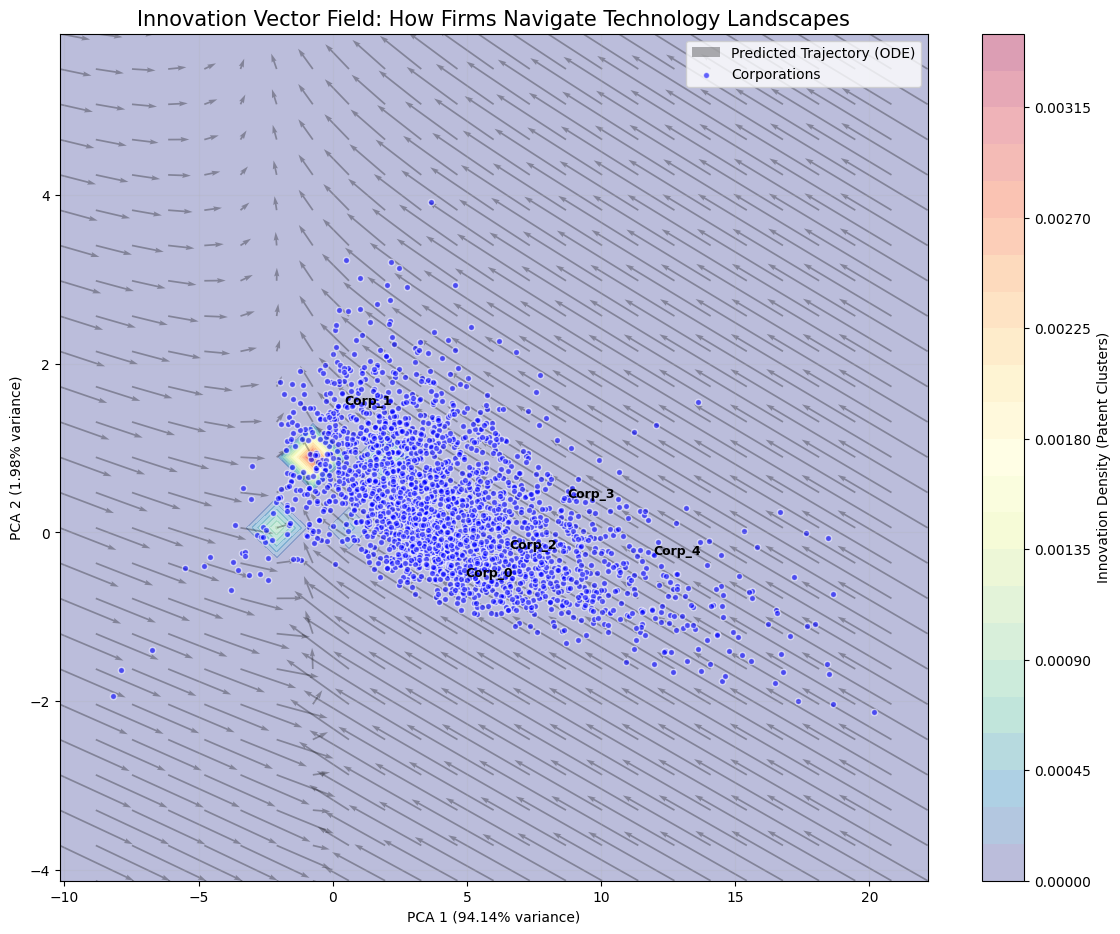

In [ ]:
# ============================================================
# セルB: Neural ODEによるベクトル場の可視化
# ============================================================
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde

def plot_innovation_flow(model, data_t, num_corps, device):
    model.eval()
    node_indices = torch.arange(model.num_nodes, device=device)
    
    with torch.no_grad():
        # 1. 潜在表現(mu)の取得と2次元圧縮
        x_f = model.get_node_features(data_t.x, node_indices)
        mu, _ = model.encoder(x_f, data_t.edge_index)
        
        mu_np = mu.cpu().numpy()
        pca = PCA(n_components=2)
        mu_2d = pca.fit_transform(mu_np)
        
        # 2. 技術の「山」を作成（特許ノードの密度分布）
        patent_2d = mu_2d[num_corps:] # 特許ノードのみ抽出
        kde = gaussian_kde(patent_2d.T)
        
        # グリッドの作成
        pad = 2.0
        x_min, x_max = mu_2d[:, 0].min() - pad, mu_2d[:, 0].max() + pad
        y_min, y_max = mu_2d[:, 1].min() - pad, mu_2d[:, 1].max() + pad
        gx, gy = np.meshgrid(np.linspace(x_min, x_max, 25), np.linspace(y_min, y_max, 25))
        grid_points_2d = np.vstack([gx.ravel(), gy.ravel()]).T
        
        # 3. ODEによるベクトル場の計算
        # グリッド点を元の潜在空間(16次元など)に逆写像
        grid_points_ld = pca.inverse_transform(grid_points_2d)
        grid_tensor = torch.tensor(grid_points_ld, dtype=torch.float32).to(device)
        
        # t=0における速度ベクトル dz/dt を取得
        t_zero = torch.tensor([0.0]).to(device)
        dz_dt = model.temporal_predictor.ode_func(t_zero, grid_tensor)
        
        # 速度ベクトルを2次元に投影
        v_2d = dz_dt.cpu().numpy() @ pca.components_.T
        
    # --- 描画 ---
    plt.figure(figsize=(14, 11))
    
    # 背景：特許の密度（イノベーションのホットスポット）
    gz = kde(grid_points_2d.T).reshape(gx.shape)
    plt.contourf(gx, gy, gz, levels=30, cmap='Spectral_r', alpha=0.4)
    plt.colorbar(label='Innovation Density (Patent Clusters)')
    
    # ベクトル場：企業の移動方向予測
    plt.quiver(gx, gy, v_2d[:, 0], v_2d[:, 1], color='black', alpha=0.3, 
               scale=15, width=0.002, label='Predicted Trajectory (ODE)')
    
    # 企業の現在地
    corp_2d = mu_2d[:num_corps]
    plt.scatter(corp_2d[:, 0], corp_2d[:, 1], s=20, c='blue', edgecolors='white', 
                alpha=0.6, label='Corporations')
    
    # 軌跡のサンプル（特定の企業数社）
    for i in range(min(5, num_corps)):
        plt.annotate(f"Corp_{i}", (corp_2d[i, 0], corp_2d[i, 1]), fontsize=9, fontweight='bold')

    plt.title("Innovation Vector Field: How Firms Navigate Technology Landscapes", fontsize=15)
    plt.xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.2%} variance)"
    plt.ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
    plt.legend(loc='upper right')
    plt.grid(alpha=0.2)
    
    plt.savefig("innovation_vector_field.png", dpi=300)
    print("✓ ベクトル場の可視化を 'innovation_vector_field.png' に保存しました。")

# 実行（ODEモデルを使用）
plot_innovation_flow(trained_model_ode, graphs[2020], num_corps, device)

In [1]:
# ============================================================
# セル: 標準化(Scaling)を導入したベクトル場可視化
# ============================================================
from sklearn.preprocessing import StandardScaler
import numpy as np

def plot_innovation_flow_scaled(model, data_t, num_corps, device):
    model.eval()
    node_indices = torch.arange(model.num_nodes, device=device)
    
    with torch.no_grad():
        # 1. 潜在表現(mu)の取得
        x_f = model.get_node_features(data_t.x, node_indices)
        mu, _ = model.encoder(x_f, data_t.edge_index)
        mu_np = mu.cpu().numpy()
        
        # --- 追加: スケーリング処理 ---
        scaler = StandardScaler()
        mu_scaled = scaler.fit_transform(mu_np) # 全次元を平均0, 分散1に
        
        # 2. 2次元圧縮 (スケーリング済みデータに対して実施)
        pca = PCA(n_components=2)
        mu_2d = pca.fit_transform(mu_scaled)
        
        # 寄与率の確認
        exp_var = pca.explained_variance_ratio_
        print(f"📊 寄与率 - PCA1: {exp_var[0]:.2%}, PCA2: {exp_var[1]:.2%}")
        
        # 3. 技術の「山」を作成
        patent_2d = mu_2d[num_corps:]
        kde = gaussian_kde(patent_2d.T)
        
        # グリッド作成
        pad = 1.0
        x_min, x_max = mu_2d[:, 0].min() - pad, mu_2d[:, 0].max() + pad
        y_min, y_max = mu_2d[:, 1].min() - pad, mu_2d[:, 1].max() + pad
        gx, gy = np.meshgrid(np.linspace(x_min, x_max, 30), np.linspace(y_min, y_max, 30))
        grid_points_2d = np.vstack([gx.ravel(), gy.ravel()]).T
        
        # 4. ODEによるベクトル場の計算
        # 2Dグリッド -> スケーリング空間(LD) -> オリジナル空間(LD) への逆変換
        grid_points_ld_scaled = pca.inverse_transform(grid_points_2d)
        grid_points_ld_orig = scaler.inverse_transform(grid_points_ld_scaled)
        
        grid_tensor = torch.tensor(grid_points_ld_orig, dtype=torch.float32).to(device)
        
        # dz/dt を取得
        t_zero = torch.tensor([0.0]).to(device)
        dz_dt = model.temporal_predictor.ode_func(t_zero, grid_tensor)
        dz_dt_np = dz_dt.cpu().numpy()
        
        # 速度ベクトルもスケーリングの影響を考慮して投影
        # (大まかには、方向成分をPCAコンポーネントで変換)
        v_2d = dz_dt_np @ pca.components_.T 
        
    # --- 描画 (前回のコードと同様) ---
    plt.figure(figsize=(12, 10))
    gz = kde(grid_points_2d.T).reshape(gx.shape)
    plt.contourf(gx, gy, gz, levels=30, cmap='Spectral_r', alpha=0.4)
    plt.quiver(gx, gy, v_2d[:, 0], v_2d[:, 1], color='black', alpha=0.3, scale=20)
    
    corp_2d = mu_2d[:num_corps]
    plt.scatter(corp_2d[:, 0], corp_2d[:, 1], s=30, c='blue', edgecolors='white', label='Firms')
    
    plt.title(f"Scaled Innovation Field (PC1:{exp_var[0]:.1%} PC2:{exp_var[1]:.1%})")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()

# 実行
plot_innovation_flow_scaled(trained_model_ode, graphs[2020], num_corps, device)

NameError: name 'trained_model_ode' is not defined


提案手法: VGAE + Neural ODE の学習


NameError: name 'graphs' is not defined